Analysis into if cmems or OSCAR is more accurate based off of the initial abbility to predict the the dFADs speeds

- Start by using compairson of CMEMs and the dFADs speeds at current time 
    Produce plot of inital cmems speed errors vs leadtime errors. 
    create a list of all the innital speed errors 


In [1]:
import numpy as np 
import pandas as pd 
import geopandas as gpd
from importlib import reload
import functions.funcs as funcs 
reload(funcs)
import matplotlib.pyplot as plt

In [2]:
ds = gpd.read_parquet(r"Data\Mappedwinds_OSCAR_SAT_MI_Cleanedspeeds.parquet") 
ds = ds.reset_index(drop = True)

fc = pd.read_csv("Parcels/saved_output/Final/cmems_bias_pers_meanremoved_2026.csv")
fc1 = pd.read_csv("Parcels/saved_output/OSCAR_2022_2025_wind.csv")

fc2 = pd.read_csv("Parcels/saved_output/optimal_cmems_OSCAR_2022_2024.csv", index_col= 0)
fc3 = pd.read_csv("Parcels/saved_output/No_forecast.csv")
fc5 = pd.read_csv("Parcels/saved_output/No_forecast2023.csv")
fc["Time"] = pd.to_datetime(fc["Time"])
fc['error_km'] = funcs.haversine_df(fc, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
fc1["Time"] = pd.to_datetime(fc1["Time"])
fc1['error_km'] = funcs.haversine_df(fc1, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
fc2["Time"] = pd.to_datetime(fc2["Time"])
fc2["error_km"] = funcs.haversine_df(fc2, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
fc3["Time"] = pd.to_datetime(fc3["Time"])
fc3["error_km"] = funcs.haversine_df(fc3, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
fc5["Time"] = pd.to_datetime(fc5["Time"])
fc5["error_km"] = funcs.haversine_df(fc5, "lat_true", "lon_true", "lat_forcast", "lon_forcast")


ds.columns

Index(['index', 'BuoyName', 'MinOfDate', 'MaxOfDate', 'TimeStamp', 'geometry',
       'x_deg', 'y_deg', 'x_km', 'y_km', 'xy_km', 'Delta_Timestamps',
       'x_speed', 'y_speed', 'xy_speed', 'points_removed', 'Masked_array',
       'points_removed2', 'Masked_array2', 'Masked_array_combined', 'mapped_v',
       'mapped_u', 'mapped_v_oscar', 'mapped_u_oscar', 'mapped_v_winds',
       'mapped_u_winds'],
      dtype='object')

### Merging True dFAD data with the forecast Data
- steps: 
1) Generate an unstacked version of dFAD data. 
2) Combine 
3) also Calculating initial Speed

In [3]:
def add_starttime(fc):
    fc["starttime"] = (fc["Time"] - pd.to_timedelta(fc["leadtime"], unit= "hours")).dt.round("min")
    return fc

In [4]:
longlist = pd.DataFrame({})
longlist["Time"] = funcs.Column_to_List(ds, "TimeStamp", idlist = False)
longlist["lats"], longlist["lons"] = funcs.list_of_latlon(ds, False)
longlist["x_speed"] = funcs.Column_to_List(ds, "x_speed", idlist = False)
longlist["y_speed"] = funcs.Column_to_List(ds, "y_speed", idlist = False)
longlist["v_mapped"], longlist["BuoyID"]  =funcs.Column_to_List(ds, "mapped_v", idlist = True)
longlist["v_mapped_OSCAR"], longlist["BuoyID"]  =funcs.Column_to_List(ds, "mapped_v_oscar", idlist = True)
longlist["u_mapped"] = funcs.Column_to_List(ds, "mapped_u", idlist = False)
longlist["u_mapped_OSCAR"] = funcs.Column_to_List(ds, "mapped_u_oscar", idlist = False)
longlist.Time = pd.to_datetime(longlist.Time)

In [5]:
## maps the True dFAD dFADs speeds onto 
def merge_forecast_true(fc, longlist):
    merged = pd.merge_asof(
    fc.sort_values('Time'),
    longlist.sort_values('Time'),
    on='Time',
    by='BuoyID',
    tolerance=pd.Timedelta(minutes=1),
    direction='nearest'
    )
    return merged

merged = merge_forecast_true(fc, longlist)
merged["speed"] = np.sqrt(merged.x_speed**2 + merged.y_speed**2)
merged["starttime"] = (merged.Time - pd.to_timedelta(merged.leadtime, "hours")).dt.round('min')
merged = merged.sort_values('leadtime') ## was time not sure if this changes results in later analysis
merged["initial_speed"] = merged.groupby(by=["BuoyID", "starttime"],  observed=False)['speed'].transform('first')

## plot for just 24 hours 
bins = np.linspace(0,8*24,2*24+1)
merged["lead_bins"] = pd.cut(merged["leadtime"], bins)
binlist = merged["lead_bins"].unique()
a  =binlist[7] ## list of bin intervals 
print(a)
mergedhr = merged.groupby("lead_bins",  observed=False).get_group(a).copy()

(24.0, 28.0]


### Speed Corrilations with errors.

In [6]:
def inital_speed_binning(merged: pd.DataFrame, binindex : int):
    bins = np.linspace(0,8*24,2*24+1)
    merged["lead_bins"] = pd.cut(merged["leadtime"], bins)
    binlist = merged["lead_bins"].unique().sort_values()
    a  =binlist[binindex] ## list of bin intervals 
    mergedhr = merged.groupby("lead_bins",  observed=False).get_group(a).copy()
    ##now group by speeds and take a mean.
    speedbins = np.linspace(0,mergedhr.initial_speed.max(),25)
    mergedhr["speed_bin"] = pd.cut(mergedhr["initial_speed"], speedbins)
    binned_errors = mergedhr.groupby("speed_bin",  observed=False)["error_km"].mean()
    return speedbins, binned_errors

speedbins, binned_errors = inital_speed_binning(merged,8)

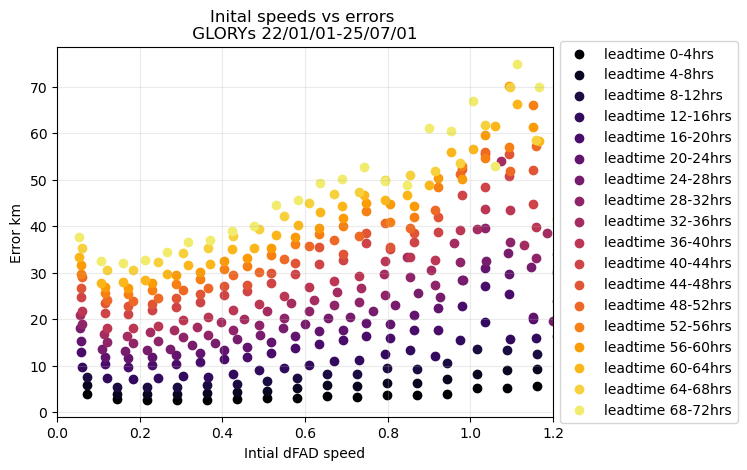

In [7]:
fig, ax = plt.subplots()
cmap = plt.cm.inferno
for i in range(18):
    speedbins, binned_errors = inital_speed_binning(merged,i+1)
    ax.scatter(speedbins[1:], binned_errors, label=f"leadtime {i*4}-{(i+1)*4}hrs", color=cmap(i/18))
ax.set_ylabel("Error km")
ax.set_xlabel("Intial dFAD speed")
ax.set_xlim(0,1.2)

ax.set_title("Inital speeds vs errors \n GLORYs 22/01/01-25/07/01 ")
ax.grid(alpha = 0.25)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

### analyzing optimal forecasting dataset
- Dataset is if we knew what Trajectory was going to produce the lowest at 72hrs
- comes from Optimal_forecast.ipynb

In [8]:
### plot simple time series of Percent cmems or OSCAR

fc2i= fc2.query("leadtime == 0").reset_index(drop = True).sort_values("Time")
fc2i["Day"] = fc2i.Time.dt.date
print(f"Fraction of cmems forecasts : {fc2i.query("model == 'cmems'")["model"].count()/fc2i.model.count() :0.4}")

percentcmems = fc2i.groupby("Day",  observed=False).apply(lambda x: (x["model"] == "cmems").sum() / len(x) * 100, include_groups = False)
percentcmems = percentcmems.to_frame().rename(columns = {0: "cmems"})
percentcmems["rolling"] = percentcmems.cmems.rolling(7).mean()

Fraction of cmems forecasts : 0.6581


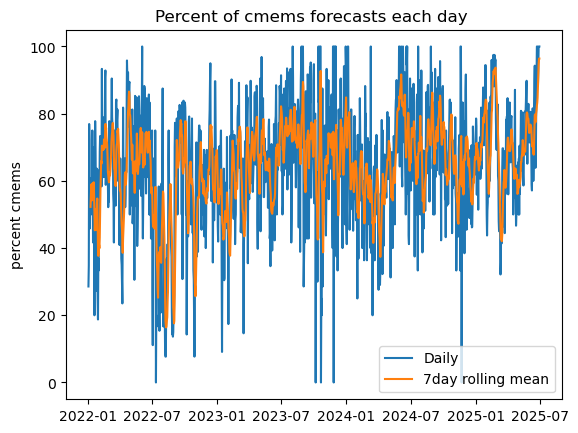

In [9]:
fig, ax = plt.subplots()
ax.plot(percentcmems.index, percentcmems.values, label = ["Daily", "7day rolling mean"])
ax.set_ylabel("percent cmems")
ax.set_title("Percent of cmems forecasts each day ")
ax.legend()

### Calculating metrics based on the initial Condition of Projection, Initial_speed_dif, initial_current_var. 
- Projection :
$$\displaystyle \frac{U_{model} \cdot U_{dfad}}{|U_{model}|}$$
- Initial_angle 
$$\displaystyle \frac{U_{model} \cdot U_{dfad}}{|U_{model}||U_{dFAD}| }$$
- Initial Speed Differance 
$$\displaystyle \sqrt{(u_{model} - u_{dFAD})^2  + (v_{model} - v_{dFAD})^2}$$


In [10]:
def calc_projection_initial_angle(merged, sufix = None):
    projection = "projection"
    angle = "angle"
    u = "u_mapped"
    v = "v_mapped"
    if sufix is not None:
        projection +=sufix
        angle +=sufix
        u += sufix
        v+= sufix 
    merged[projection] = (merged.y_speed * merged[v])+ (merged.x_speed * merged[u])
    merged[projection]  = merged[projection]/(merged.x_speed**2 +merged.y_speed**2 )**(1/2)
    merged[angle] = merged[projection]/(merged[u]**2 +merged[v]**2 )**(1/2)
    merged[angle] = np.arccos(merged[angle])*180/np.pi
    merged = merged.sort_values("leadtime")
    merged["initial_"+angle] =  merged.groupby(["BuoyID", "starttime"],  observed=False)[angle].transform("first")
    merged["initial_"+projection] = merged.groupby(["BuoyID", "starttime"],  observed=False)[projection].transform("first")
    return merged

def calc_intial_speed_dif(merged, sufix= None):
    initial_speed_dif_mag = "initial_speed_dif_mag" 
    speed_dif_mag = "speed_dif_mag"
    u = "u_mapped"
    v = "v_mapped"
    if sufix is not None:
        initial_speed_dif_mag +=sufix
        speed_dif_mag +=sufix
        u += sufix
        v+= sufix 
    merged[speed_dif_mag] = np.sqrt((merged.x_speed - merged[u])**2 + (merged.y_speed - merged[v])**2)
    merged[initial_speed_dif_mag] = merged.groupby(["BuoyID", "starttime"],  observed=False)[speed_dif_mag].transform("first")
    return merged

def inital_current_var(merged,sufix = None):
    import xarray as xr
    cmems = xr.open_dataset(r"Data\cmems.nc")
    varu = cmems.sel(latitude = slice(4.5, 7.5), depth = 15.81007).uo.var(dim = ["latitude", "longitude"])
    varv = cmems.sel(latitude = slice(4.5, 7.5), depth = 15.81007).vo.var(dim = ["latitude", "longitude"])
    varts = pd.DataFrame({"startday": varu.time.values, "varu": varu.values, "varv": varv.values})
    varts["var"] = varts.varu + varts.varv
    varts['startday'] = varts.startday.dt.date
    #merged["startday"] = merged.starttime.dt.date
    merged["startday"] = merged.groupby(['BuoyID', 'starttime'], observed= False)['starttime'].transform('first')
    merged['startday'] = merged['startday'].dt.date
    mergedvar = pd.merge(merged, varts, how = "left",on =  "startday")
    return mergedvar

def calc_iniial_lat(merged):
    merged = merged.sort_values("leadtime")
    merged["initial_lat"] = merged.groupby(["BuoyID", 'starttime'])["lat_true"].transform("first")
    return merged

#cmems all years
merged = merge_forecast_true(fc, longlist)
merged = add_starttime(merged)
merged = calc_projection_initial_angle(merged)
merged = calc_projection_initial_angle(merged, sufix = "_OSCAR")
merged = calc_intial_speed_dif(merged)
merged = calc_intial_speed_dif(merged, "_OSCAR")
merged = inital_current_var(merged)
merged = calc_iniial_lat(merged)

# cmems by year
merged02 = merged[(merged.starttime > pd.Timestamp("2022-01-01")) & (merged.starttime < pd.Timestamp("2023-01-01"))]
merged03 = merged[(merged.starttime > pd.Timestamp("2023-01-01")) & (merged.starttime < pd.Timestamp("2024-01-01"))]
merged04 = merged[(merged.starttime > pd.Timestamp("2024-01-01")) & (merged.starttime < pd.Timestamp("2025-01-01"))]
merged05 = merged[(merged.starttime > pd.Timestamp("2025-01-01")) & (merged.starttime < pd.Timestamp("2026-01-01"))]


def Projection_binning(merged: pd.DataFrame, label:str, binindex : int):
    bins = np.linspace(0,8*24,2*24+1)
    merged["lead_bins"] = pd.cut(merged["leadtime"], bins)
    binlist = merged["lead_bins"].unique().sort_values()
    a  =binlist[binindex] ## list of bin intervals 
    mergedhr = merged.groupby("lead_bins",  observed=False).get_group(a).copy()
    ##now group by speeds and take a mean.
    speedbins = np.linspace(mergedhr[label].min(),mergedhr[label].max(),20)
    mergedhr["projection_bin"] = pd.cut(mergedhr[label], speedbins)
    binned_errors = mergedhr.groupby("projection_bin",  observed=False)["error_km"].mean()
    return speedbins, binned_errors



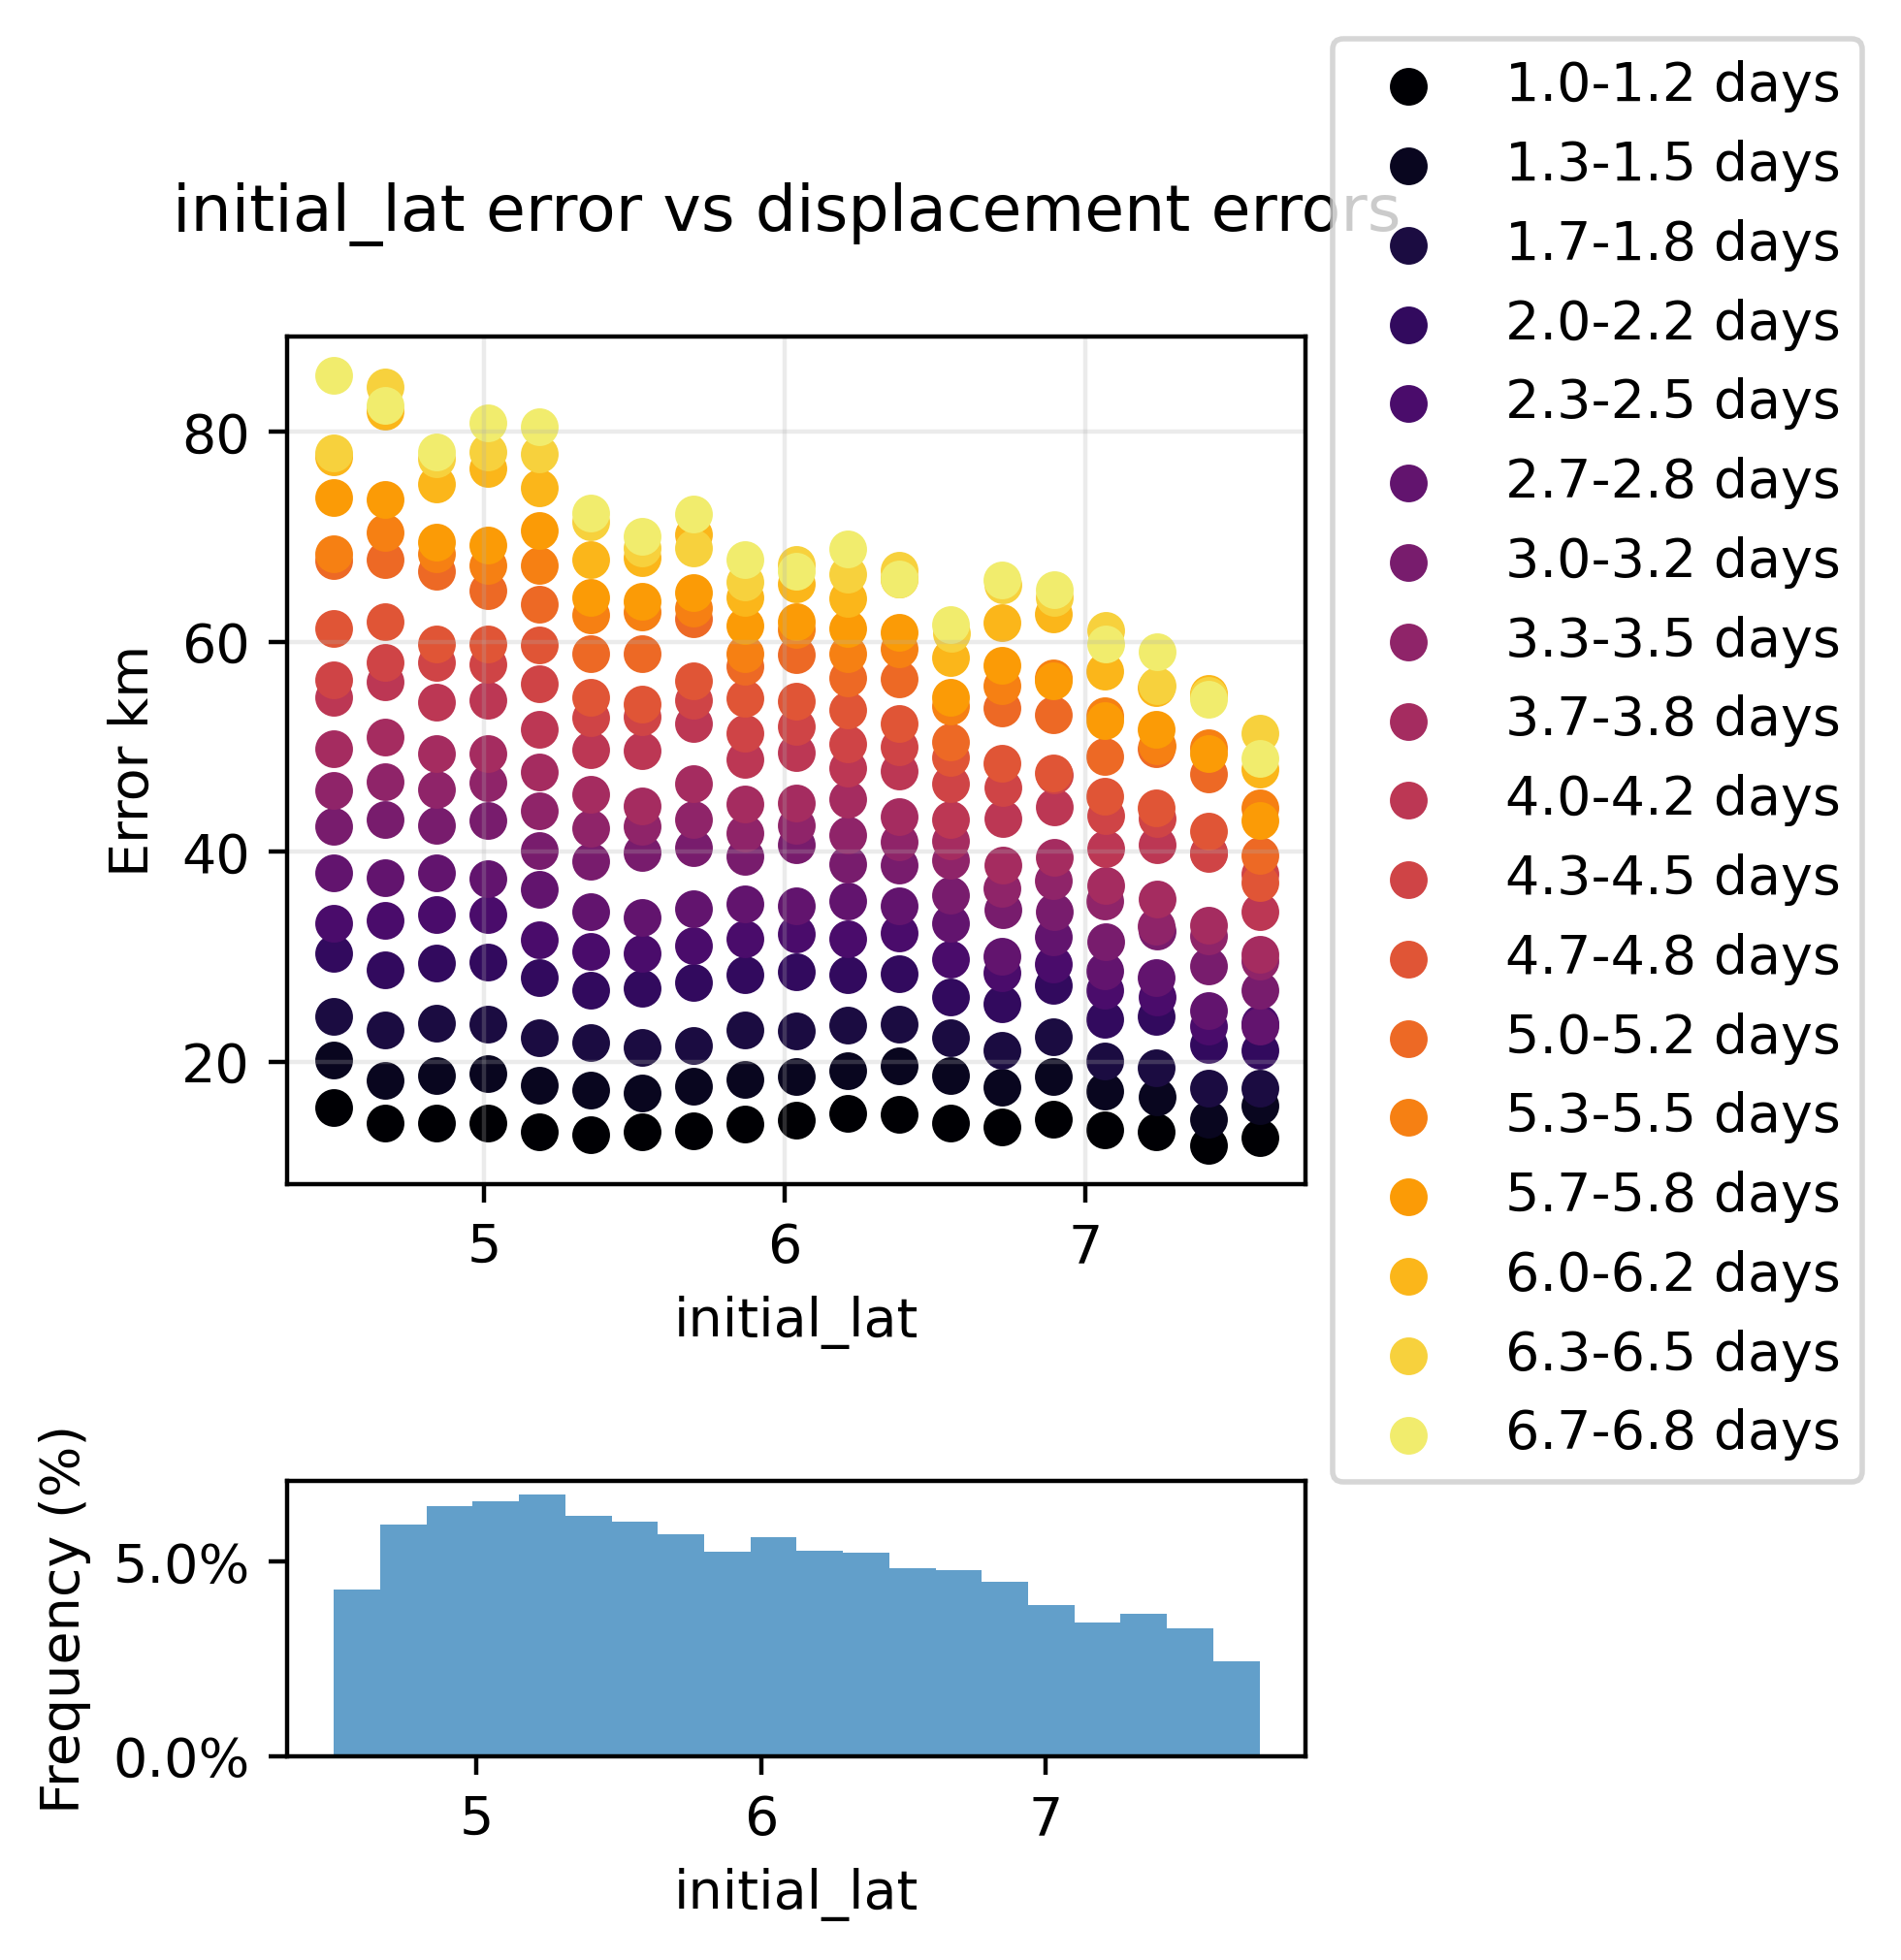

In [31]:
import matplotlib.gridspec as gridspec
from matplotlib.ticker import PercentFormatter
fig = plt.figure(figsize=(5,5), dpi = 400)
gs = gridspec.GridSpec(3, 1)
ax = fig.add_subplot(gs[-1])
ax1 = fig.add_subplot(gs[:-1])
cmap = plt.cm.inferno
ofset = 6## ofsets in 4 hour incruments  # this is the start time if ofset = 6, first time plotted with 24hr. 
timerange = 18
variable = "initial_lat"
for i in range(timerange):
    speedbins, binned_errors = Projection_binning(merged,variable, i*2+ofset)
    ax1.scatter(speedbins[binned_errors.index.codes], binned_errors, label=f"{round((i*2+ofset)*4/24,1)}-{round((i*2+ofset+1)*4/24, 1)} days", color=cmap(i/timerange))

nbins = 20
counts, bin_edges = np.histogram(merged[variable].dropna(), bins=nbins)
ax.bar(bin_edges[:-1], counts / counts.sum() * 100, width=np.diff(bin_edges), align='edge', alpha=0.7)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_ylabel("Frequency (%)")
ax.set_xlabel(variable)
#ax.set_xlim(0,0.8)

ax1.set_ylabel("Error km")
ax1.set_xlabel(variable)
#ax1.set_xlim(0,0.8)
#ax.set_ylim(0,60)
ax1.set_title(f"{variable} error vs displacement errors \n ")
ax1.grid(alpha = 0.25)
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.tight_layout()
fig.savefig(r'..\Figures\Paper\FIG4.pdf')

### initial Speed and Latitude Corrialtion

[4.5 5.  5.5 6.  6.5 7.  7.5] [0.         0.14285714 0.28571429 0.42857143 0.57142857 1.        ]
(5, 6)


Text(0.5, 1.0, '0.7 Quantile vs latitude and Speed Difference \n Number are amount points in each bin \n Errors at leadtime: 72 hrs')

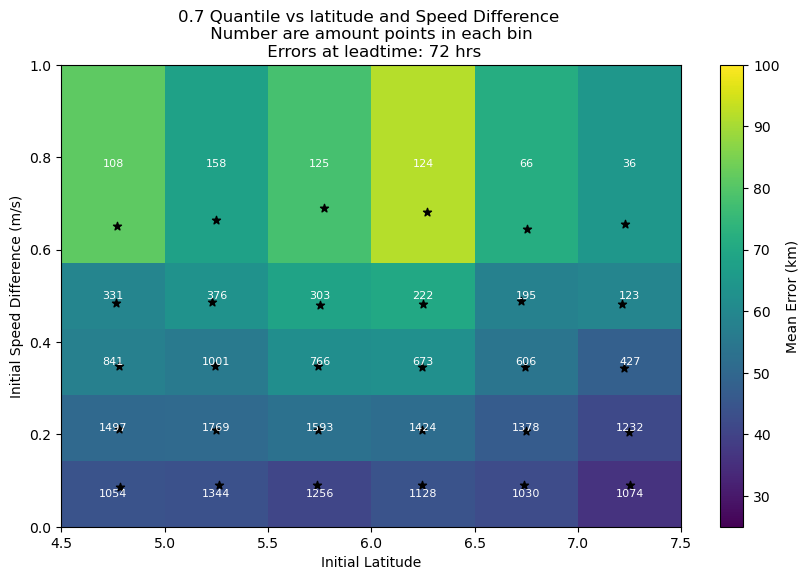

In [ ]:
## making a plot of intial angle error and speed error, 
# need to calculate speed error 
# merged.initial_speed is the speed of dFAD at time zero. 

angle_var = "initial_angle"
speed_var = "initial_speed_dif_mag"
lat_var  = "initial_lat"
plot_variables = ["initial_lat", "initial_speed_dif_mag"]

merged = merged.sort_values(by = "leadtime")
target_leadtime = 24*3-2
merged_start = merged.query("leadtime > @target_leadtime").drop_duplicates(subset = ["BuoyID", "starttime"])
target_leadtime_upper = target_leadtime + 12
merged_start = merged_start.query("leadtime < @target_leadtime_upper") 


# Create 2D bins for initial_angle and initial_speed_dif_mag
angle_bins = np.linspace(0, 180, 8)
speed_bins = np.linspace(0, 1, 8)
lat_bins = np.arange(4.5,7.75,0.5)
speed_bins = np.delete(speed_bins, [-3,-2])
print(lat_bins, speed_bins)
# Bin the data
merged_start["angle_bin"] = pd.cut(merged_start[angle_var], angle_bins)
merged_start["speed_bin"] = pd.cut(merged_start[speed_var], speed_bins)
merged_start["lat_bin"] = pd.cut(merged_start["initial_lat"], lat_bins)
# Calculate mean error for each 2D bin
binned_data = merged_start.groupby(["lat_bin", "speed_bin"], observed=False)['error_km'].quantile(0.7).reset_index() #Calc Quantile 
lat_centers = merged_start.groupby(["lat_bin", "speed_bin"], observed=False)['initial_lat'].mean().reset_index() # Calc, centers of each bin 
speed_center = merged_start.groupby(["lat_bin", "speed_bin"], observed=False)['initial_speed_dif_mag'].mean().reset_index() # Calc, centers of each bin 
binned_pivot = binned_data.pivot_table(index="speed_bin", columns="lat_bin", values="error_km", observed = False)
centers = pd.merge(lat_centers, speed_center, how = 'left')
stacked = binned_pivot.stack().rename('error_km').reset_index(drop = False)
# Create meshgrid for pcolormesh

angle_mesh, speed_mesh = np.meshgrid(lat_bins, speed_bins)

# Convert binned_pivot to 2D array for pcolormesh
error_values = binned_pivot.values
print(error_values.shape)
fig, ax = plt.subplots(figsize=(10, 6))
pcm = ax.pcolormesh(angle_mesh, speed_mesh, error_values, cmap='viridis', vmin=25, vmax=100)
cbar = fig.colorbar(pcm, ax=ax, label="Mean Error (km)")
ax.scatter(centers.initial_lat, centers.initial_speed_dif_mag, marker = '*', color = 'k')
#pcm.set_clim(10,120)

counts = merged_start.groupby(["lat_bin", "speed_bin"], observed=False).size().reset_index(name="count")
counts_pivot = counts.pivot(index="speed_bin", columns="lat_bin", values="count")
count_values = counts_pivot.values
angle_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
speed_centers = (speed_bins[:-1] + speed_bins[1:]) / 2
angle_cent_mesh, speed_cent_mesh = np.meshgrid(angle_centers, speed_centers)
for (i, j), val in np.ndenumerate(count_values):
    cnt = count_values[i, j]
    if np.isnan(cnt):
        continue
    x = angle_cent_mesh[i, j]
    y = speed_cent_mesh[i, j]
    err = error_values[i, j] if not np.isnan(error_values[i, j]) else 0
    #text_color = "white" if err > (pcm.get_clim()[1] * 0.45) else "black"
    ax.text(x, y, int(cnt), ha="center", va="center", color="white", fontsize=8)
# <-- END INSERTION

ax.set_xlabel("Initial Latitude")
ax.set_ylabel("Initial Speed Difference (m/s)")
ax.set_title(f"0.7 Quantile vs latitude and Speed Difference \n Number are amount points in each bin \n Errors at leadtime: {target_leadtime +2} hrs")

#### removing initial angle varience 

C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_23652\901073767.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_speed_lists = [group.tolist() for name, group in angle_slice.groupby("speed_bin")["error_km"]]
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_23652\901073767.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_speed_lists = [group.tolist() for name, group in angle_slice.groupby("speed_bin")["error_km"]]
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_23652\901073767.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future ver

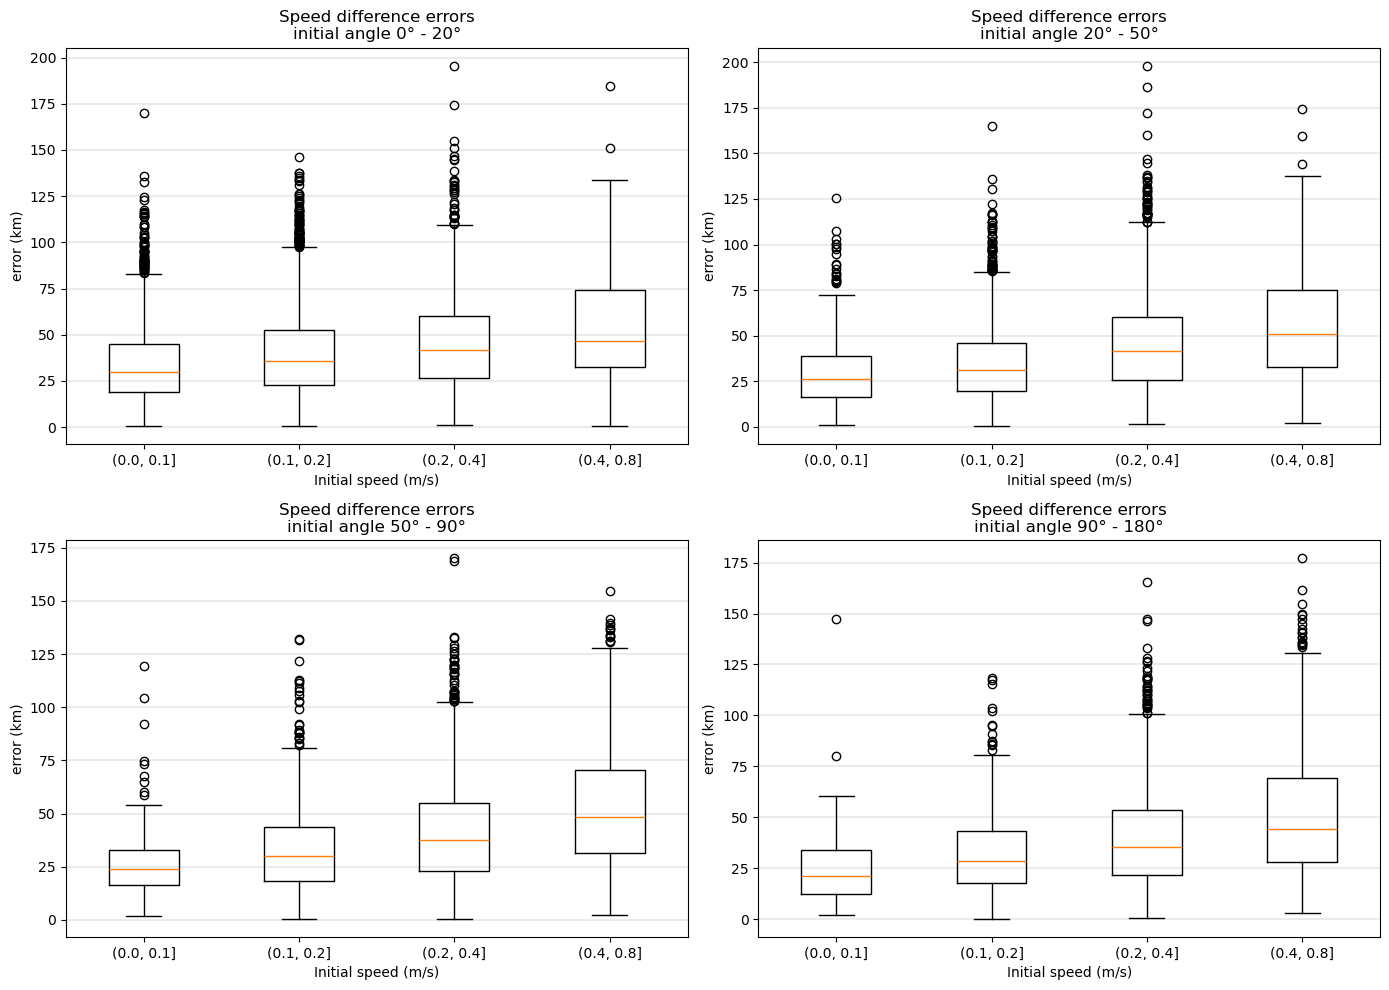

In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
axs = [ax1, ax2, ax3, ax4]

# Define parameters for each subplot
params = [
    {"lowerbound": 0, "higherbound": 20, "ax": ax1},
    {"lowerbound": 20, "higherbound": 50, "ax": ax2},
    {"lowerbound": 50, "higherbound": 90, "ax": ax3},
    {"lowerbound": 90, "higherbound": 180, "ax": ax4},
]

for i, param in enumerate(params):
    lowerbound = param["lowerbound"]
    higherbound = param["higherbound"]
    ax = param["ax"]
    
    angle_slice = merged_start[merged_start.initial_angle > lowerbound]
    angle_slice = angle_slice[angle_slice.initial_angle < higherbound].reset_index(drop=True)
    bins = np.linspace(0, 0.8, 4)
    bins = np.array([0, 0.1, 0.2, 0.4, 0.8])
    angle_slice["speed_bin"] = pd.cut(angle_slice.initial_speed_dif_mag, bins)
    grouped_speed_lists = [group.tolist() for name, group in angle_slice.groupby("speed_bin")["error_km"]]
    bins_list = angle_slice.speed_bin.unique().sort_values()
    
    ax.boxplot(grouped_speed_lists, tick_labels=bins_list[:-1])
    ax.grid(axis="y", alpha=0.25, lw=1.5)
    ax.set_xlabel("Initial speed (m/s)")
    ax.set_ylabel("error (km)")
    ax.set_title(f"Speed difference errors\ninitial angle {lowerbound}° - {higherbound}°")
    # ax.set_ylim(0, 150)

plt.tight_layout()

#### Removing Initial Speed, Focusing on just inital angle varience. 


C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_23652\798291173.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_angle_lists = [group.tolist() for name, group in speed_slice.groupby("angle_bin")["error_km"]]
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_23652\798291173.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_angle_lists = [group.tolist() for name, group in speed_slice.groupby("angle_bin")["error_km"]]
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_23652\798291173.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future ver

4 4
4 4
4 4
4 4


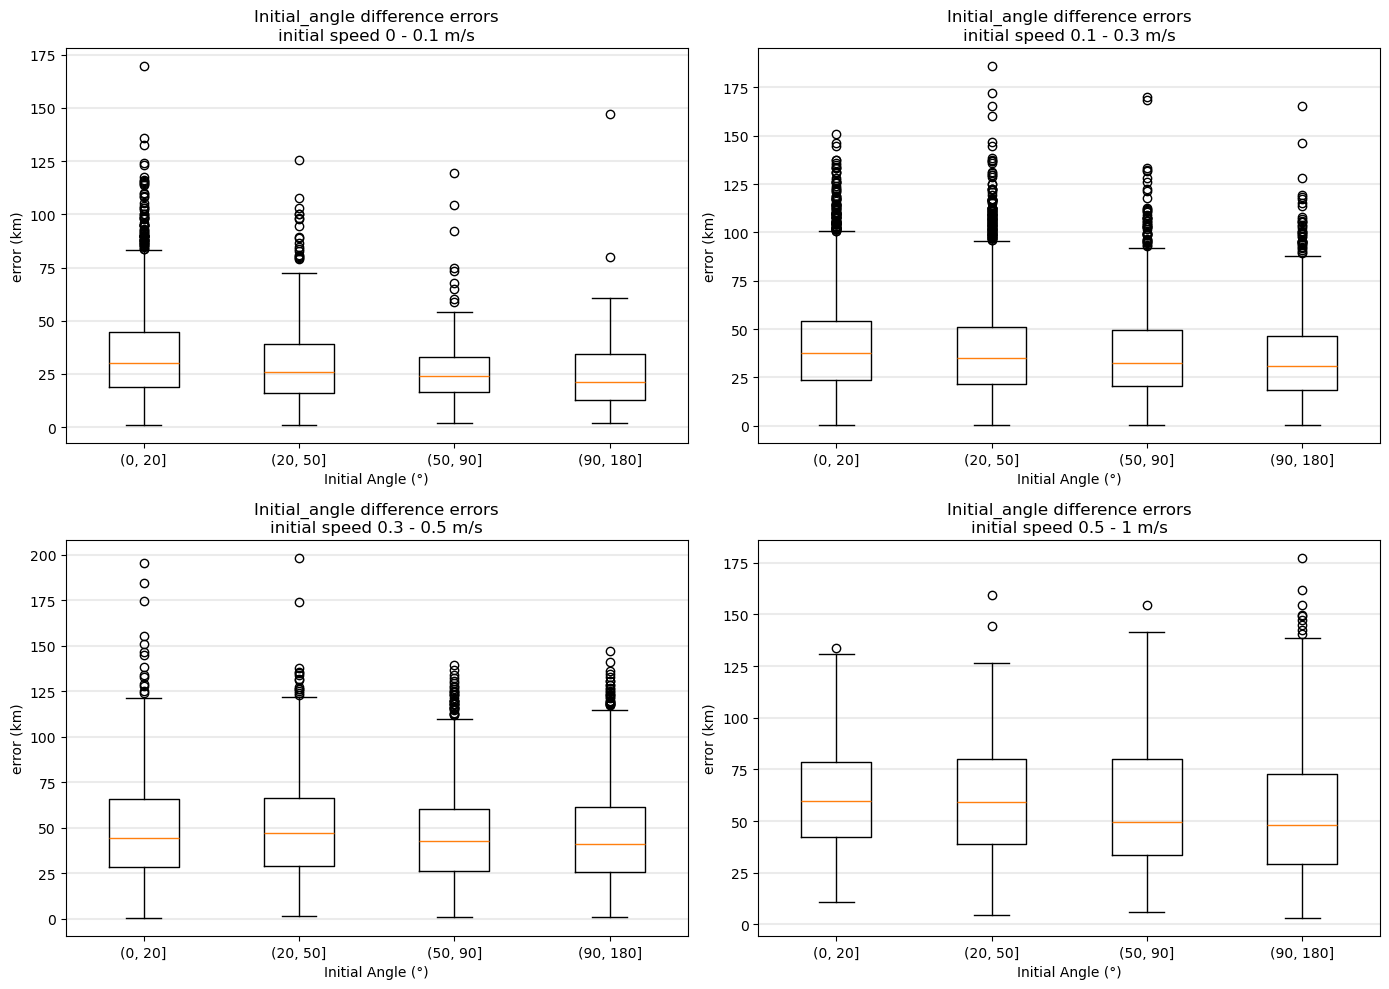

In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
axs = [ax1, ax2, ax3, ax4]

# Define parameters for each subplot
params = [
    {"lowerbound": 0, "higherbound": 0.1, "ax": ax1},
    {"lowerbound": 0.1, "higherbound": 0.3, "ax": ax2},
    {"lowerbound": 0.3, "higherbound": 0.5, "ax": ax3},
    {"lowerbound": 0.5, "higherbound": 1, "ax": ax4},
]

for i, param in enumerate(params):
    lowerbound = param["lowerbound"]
    higherbound = param["higherbound"]
    ax = param["ax"]
    speed_slice = merged_start[merged_start.initial_speed_dif_mag > lowerbound]
    speed_slice = speed_slice[speed_slice.initial_speed_dif_mag < higherbound].reset_index(drop = True)
    bins = np.linspace(0,170,6)
    bins = np.array([0, 20, 50, 90, 180])
    speed_slice["angle_bin"] = pd.cut(speed_slice.initial_angle, bins)
    grouped_angle_lists = [group.tolist() for name, group in speed_slice.groupby("angle_bin")["error_km"]]
    bins_list = speed_slice.angle_bin.unique().sort_values()
    print(len(grouped_angle_lists), len(bins_list))
    ax.boxplot(grouped_angle_lists, tick_labels=bins_list[:])
    ax.grid(axis="y", alpha=0.25, lw=1.5)
    ax.set_xlabel("Initial Angle (°)")
    ax.set_ylabel("error (km)")
    ax.set_title(f"Initial_angle difference errors\ninitial speed {lowerbound} - {higherbound} m/s")
    #ax.set_ylim(0, 150)
fig.tight_layout()

#### Removing latitude from initial speed dif

[4.5 5.1 5.7 6.3 6.9]


C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_23652\868910206.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_speed_lists = [group.tolist() for name, group in lat_slice.groupby("speed_bin")["error_km"]]
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_23652\868910206.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_speed_lists = [group.tolist() for name, group in lat_slice.groupby("speed_bin")["error_km"]]
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_23652\868910206.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version

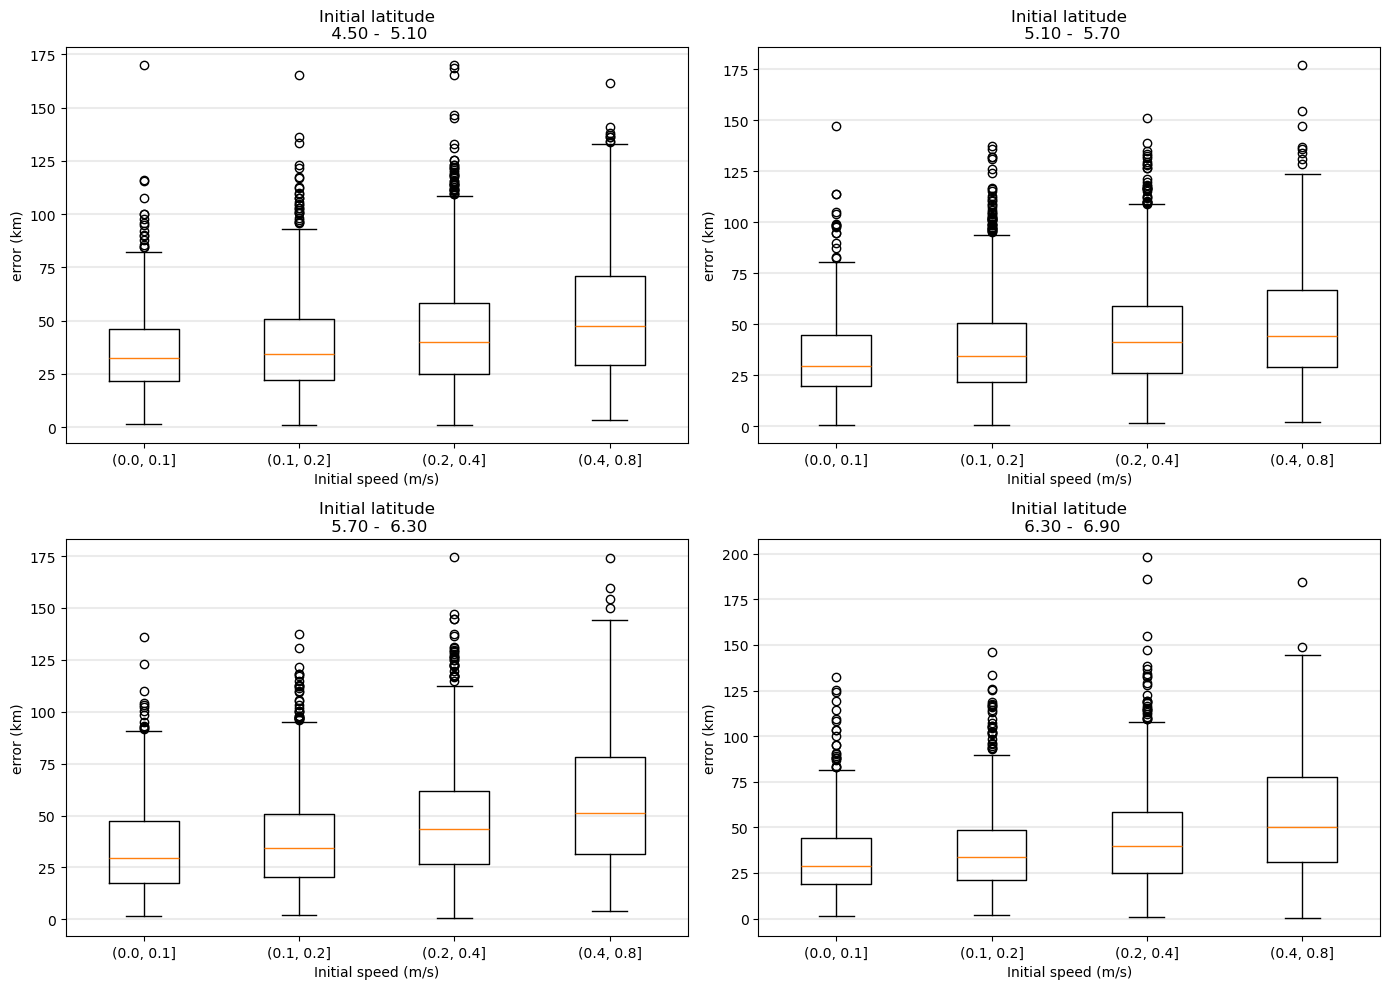

In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
axs = [ax1, ax2, ax3, ax4]

# Define parameters for each subplot
bounds = np.arange(4.5,7.5,3/5)
print(bounds)
for i in range(len(bounds)-1):
    lowerbound = bounds[i]
    higherbound = bounds[i+1]
    ax = axs[i]
    
    lat_slice = merged_start[merged_start.initial_lat > lowerbound]
    lat_slice = lat_slice[lat_slice.initial_lat < higherbound].reset_index(drop=True)
    bins = np.linspace(0, 0.8, 4)
    bins = np.array([0, 0.1, 0.2, 0.4, 0.8])
    lat_slice["speed_bin"] = pd.cut(lat_slice.initial_speed_dif_mag, bins)
    grouped_speed_lists = [group.tolist() for name, group in lat_slice.groupby("speed_bin")["error_km"]]
    bins_list = lat_slice.speed_bin.unique().sort_values()
    
    ax.boxplot(grouped_speed_lists, tick_labels=bins_list[:-1])
    ax.grid(axis="y", alpha=0.25, lw=1.5)
    ax.set_xlabel("Initial speed (m/s)")
    ax.set_ylabel("error (km)")
    ax.set_title(f"Initial latitude\n{lowerbound : .2f} - {higherbound: .2f}")
    # ax.set_ylim(0, 150)

plt.tight_layout()

#### Isolating Latitude from angle 

[0.  0.1 0.2 0.4 0.8]


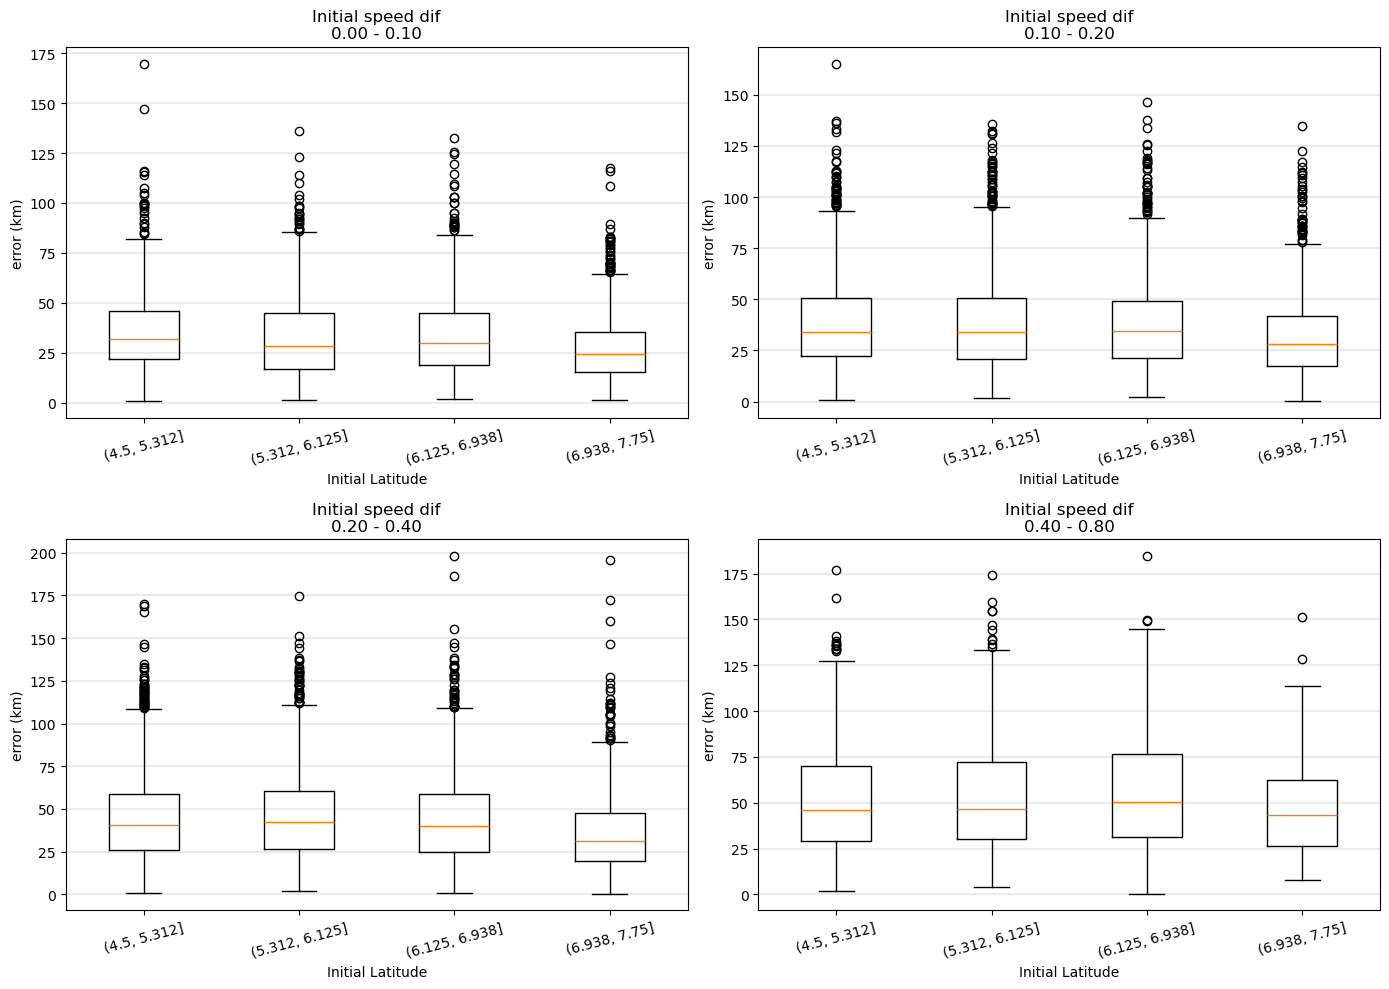

In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
axs = [ax1, ax2, ax3, ax4]

# Define parameters for each subplot
bounds = np.array([0, 0.1, 0.2, 0.4, 0.8])
print(bounds)
for i in range(len(bounds)-1):
    lowerbound = bounds[i]
    higherbound = bounds[i+1]
    ax = axs[i]
    
    speed_slice = merged_start[merged_start.initial_speed_dif_mag > lowerbound]
    speed_slice = speed_slice[speed_slice.initial_speed_dif_mag < higherbound].reset_index(drop=True).copy()

    bins = np.linspace(4.5, 7.75, 5)
    speed_slice["lat_bin"] = pd.cut(speed_slice.initial_lat, bins)

    # Keep labels and data together to avoid length mismatches; skip empty groups
    grouped = [(name, group["error_km"].tolist())
               for name, group in speed_slice.groupby("lat_bin", observed=True)
               if len(group) > 0]

    if grouped:
        bins_list, grouped_speed_lists = zip(*grouped)
        ax.boxplot(grouped_speed_lists, tick_labels=bins_list)

    ax.grid(axis="y", alpha=0.25, lw=1.5)
    ax.tick_params(axis='x', labelrotation=15)
    ax.set_xlabel("Initial Latitude")
    ax.set_ylabel("error (km)")
    ax.set_title(f"Initial speed dif\n{lowerbound:.2f} - {higherbound:.2f}")
    # ax.set_ylim(0, 150)

plt.tight_layout()


### Using Quartile linear regression to predict errors of each quartile 
 - Using intial Latitude and Speed dif

[0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]


c:\Users\czerfass\AppData\Local\miniforge3\envs\parcels\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


Text(0.5, 1.0, 'quantile regression with inital angle and speed differnces \n intial angle error: 4.5')

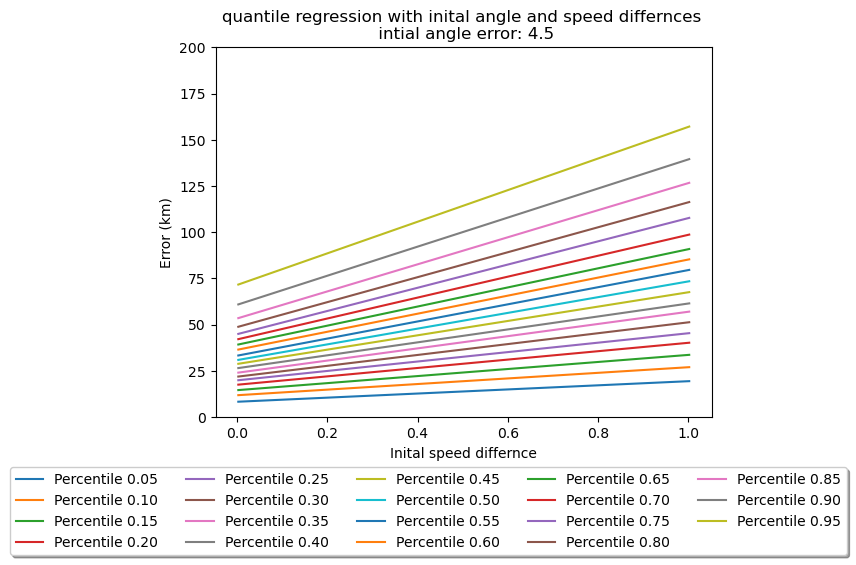

In [ ]:
import statsmodels.formula.api as smf

merged_start ## this is all errors at 72 hours. 

model = smf.quantreg("error_km ~  initial_lat+ initial_speed_dif_mag ", merged_start)
quartiles_range = np.linspace(0.05, 0.95, 19)
print(quartiles_range)
initial_speed_dif_mag = np.arange(merged_start.initial_speed_dif_mag.min(), merged_start.initial_speed_dif_mag.max(), 0.05)
target_lat= 4.5
models = []

fig, ax = plt.subplots()
for n in quartiles_range: 
    res = model.fit(q=n)
    models.append(res)
    y = res.params["Intercept"] + res.params["initial_speed_dif_mag"]*initial_speed_dif_mag + res.params["initial_lat"]*target_lat
    ax.plot(initial_speed_dif_mag, y, label =f"Percentile {n:.2f}")

fig.legend(loc='upper center', bbox_to_anchor=(3.2/7, 0.02),
        fancybox=True, shadow=True, ncol=5)

ax.set_xlabel("Inital speed differnce")
ax.set_ylim(0,200)
ax.set_ylabel("Error (km)")
ax.set_title(f"quantile regression with inital angle and speed differnces \n intial angle error: {target_lat}")

    


Intercept        57.946640
initial_lat      -3.558059
initial_speed    56.578504
Name: 0.7, dtype: float64
(5, 6)
(30, 8)


Text(0.5, 1.0, 'Perdicted error Based off Inital Speed error and intial latitude\n Quantile: 0.70\n at leadtime: 72 \n  z = 57.95 +-3.558* lat + 56.58 * Speed error ')

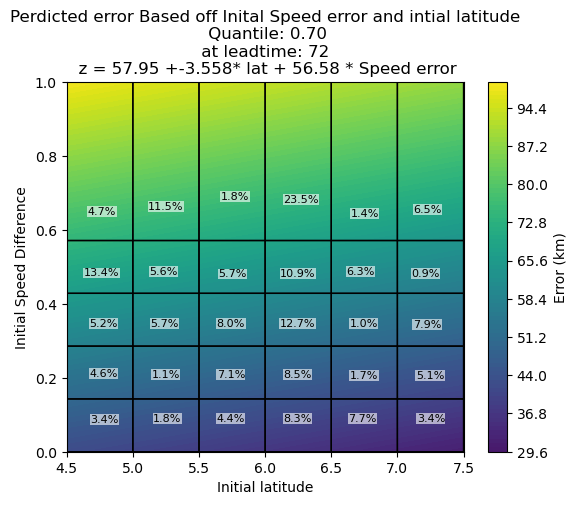

In [ ]:
## generating 2d plot 
intercepts = []
initial_lat_a  = []
initial_speed_b = []
for model in models: 
    initial_lat_a.append(model.params["initial_lat"])
    intercepts.append(model.params["Intercept"])
    initial_speed_b.append(model.params["initial_speed_dif_mag"])

quartiles = pd.DataFrame({ "Intercept": intercepts, "initial_lat": initial_lat_a,"initial_speed": initial_speed_b  }, index = quartiles_range)
ispeed_range = np.arange(0,1,0.001)
iangle_range = np.arange(4.5,7.75,0.001)
target = 13
q = quartiles.iloc[target]
quan= quartiles.index[target] 
print(q)
# calcuating percent error of the regression
q70 = quartiles.loc[0.70]
centers['predicted_errors'] =q70.Intercept + q70.initial_speed*centers.initial_speed_dif_mag + q70.initial_lat*centers.initial_lat
centers_stacked = pd.merge(centers, stacked, on = [ 'lat_bin', 'speed_bin'], how = 'left')
centers_stacked['error'] = centers_stacked.error_km - centers_stacked.predicted_errors
centers_stacked[['lat_bin' , 'speed_bin', 'error']]
centers_stacked['percent_error'] = np.abs(centers_stacked.error)/centers_stacked.predicted_errors
centers_pivot = centers_stacked.pivot_table(index="speed_bin", columns="lat_bin", values="percent_error", observed = False, dropna= False)
print(centers_pivot.to_numpy().shape)
angle_mesh, speed_mesh = np.meshgrid(lat_bins, speed_bins)
masked_data = np.ma.masked_invalid(centers_pivot.to_numpy())


X,Y = np.meshgrid( iangle_range, ispeed_range)
error_values = q.Intercept  + q.initial_lat*X + q.initial_speed*Y
fig, ax = plt.subplots()
cbar = ax.contourf(X,Y,error_values, levels = 100, cmap='viridis', vmin=25, vmax=100)

ax.pcolor(angle_mesh, speed_mesh, masked_data, facecolor='none', edgecolor='black', linewidth=1)

to_label = centers_stacked.dropna(subset=["initial_lat", "initial_speed_dif_mag", "percent_error"])
print(to_label.shape)
for _, row in to_label.iterrows():
    ax.text(
        row["initial_lat"],
        row["initial_speed_dif_mag"],
        f"{row['percent_error']*100:.1f}%",
        ha="center",
        va="center",
        fontsize=8,
        color="black",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.6, pad=0.3),
    )
#ax.contour(X,Y,error_values, levels = np.arange(25, 150, 25), colors = "k", ls = "--", alpha = 0.5)
fig.colorbar(cbar, label = "Error (km)")
ax.set(xlim = [4.5,7.5])
ax.set_xlabel("Initial latitude")
ax.set_ylabel("Initial Speed Difference")
ax.set_title(f"Perdicted error Based off Inital Speed error and intial latitude\n Quantile: {quan:.2f}\n at leadtime: {target_leadtime+2} \n  z = { q.Intercept:.2f} +{q.initial_lat:.3f}* lat + {q.initial_speed:.2f} * Speed error ")


In [ ]:

R_s = 1 - np.sum((centers_stacked.error_km - centers_stacked.predicted_errors)**2)/np.sum((centers_stacked.error_km - np.mean(centers_stacked.error_km))**2)
print(R_s)

0.8469439799177698


#### Developing a better analysis between initial angle error and initial speed difference 

1) split into meaningful quadrents. 
    - quadrents should include a statistically significant amount of data. 
        - quaderrents areas do not have to be the same size 
        -   width and high and quadrent do not need to be the same size also
            - size needs to be showuing error differances greater than bootstapping distributions. satistically significnat in each direction of the axis. 
            so we can confidently say that moving in one direction has a diffent error. 
    - could do boot strapping to show uncertainties because of forecasts generated. 
2) within each quadrent generate the expected error spreads. 
3) 

In [ ]:
## checking making thing the initial 

merged_leadtime = merged.query("leadtime == 0 ")
# print(merged_leadtime[["initial_speed_dif_mag", "BuoyID"]].sort_index().head(40))
# print(merged_start[["initial_speed_dif_mag", "BuoyID"]].sort_index().head(20))
grouped = merged.groupby(["BuoyID", "starttime"])

# Method 1: Get a specific group by name (tuple of group keys)
first_group_name = ('ISD+496035', pd.Timestamp('2024-11-07 00:01:00'))
first_group = grouped.get_group(first_group_name)

# Method 2: Iterate and get the nth group
n = 0  # Get first group (0-indexed)
for i, (name, group) in enumerate(grouped):
    if i == n:
        first_group = group
        first_group_name = name
        break

# Method 3: Convert to list of groups (use with caution on large datasets)
groups_list = [group for name, group in grouped]
first_group = groups_list[10]

In [ ]:
## remove duplicate forecasts
def add_inital_time(ds:pd.DataFrame):
    """adds intial time of forecast (time - leadtime) and changes collumns to pd.DateTime objects"""
    ds["Time"] = pd.to_datetime(ds["Time"])
    ds["initial_time"] =  ds["Time"] - pd.to_timedelta(ds["leadtime"], unit = "hours")
    ds["initial_time"] = ds["initial_time"].dt.round(freq = "min")
    return ds
merged = add_inital_time(merged)
merged_clean = merged.drop_duplicates(subset=['BuoyID', 'initial_time', 'leadtime'], keep='first')

In [ ]:
### merging forecast data with mapped speeds
oscar = fc2.query("model == 'OSCAR'").reset_index(drop = True)
oscar_merged = merge_forecast_true(oscar, longlist)
oscar_merged = oscar_merged.rename(columns= {"u_mapped_OSCAR" : "u_mapped_comb", "v_mapped_OSCAR": "v_mapped_comb"})

cmems = fc2.query("model =='cmems'").reset_index(drop = True)
cmems_merged = merge_forecast_true(cmems, longlist)
cmems_merged = cmems_merged.rename(columns= {"u_mapped" : "u_mapped_comb", "v_mapped": "v_mapped_comb"})
fc_opt = pd.concat([cmems_merged, oscar_merged])

fc_opt["projection"] = (fc_opt.y_speed * fc_opt.v_mapped_comb)+ (fc_opt.x_speed * fc_opt.u_mapped_comb)
fc_opt["projection"]  = fc_opt["projection"]/(fc_opt.x_speed**2 +fc_opt.y_speed**2 )**(1/2)
fc_opt["initial_angle"] = fc_opt["projection"]/(fc_opt.u_mapped_comb**2 +fc_opt.v_mapped_comb**2 )**(1/2)
fc_opt["initial_angle"] = np.arccos(fc_opt["initial_angle"])*180/np.pi
fc_opt_saved = fc_opt.copy()

32995

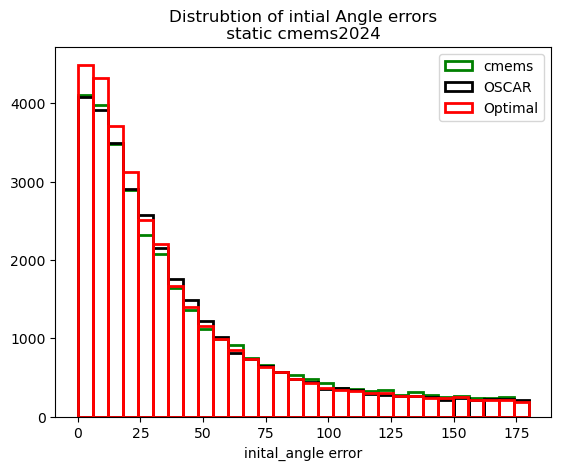

In [ ]:
### distribution of inittial error speeds. 
initial_speeds = merged_clean.query("leadtime == 0")
initial_speeds_opt = fc_opt.query("leadtime == 0")
Greater90 = initial_speeds.query("initial_angle > 90")["initial_angle"].count()
fig, ax =plt.subplots()
ax.hist(initial_speeds.initial_angle, 30, fill= None, edgecolor = "g", lw =2, label = "cmems")
ax.hist(initial_speeds.initial_angle_OSCAR, 30, fill= None, edgecolor = "k", lw = 2, label = "OSCAR")
ax.hist(initial_speeds_opt.initial_angle, 30, fill= None, edgecolor = "r", lw = 2, label = "Optimal")
ax.set_xlabel("inital_angle error")
ax.set_title("Distrubtion of intial Angle errors\n static cmems2024 ")
ax.legend()
Greater90/initial_speeds.initial_angle.count()
initial_speeds.shape[0]
initial_speeds_opt.shape[0]

In [ ]:
## checking number of forecasts 
print(initial_speeds.shape, initial_speeds_opt.shape)

(31995, 44) (32995, 22)


### Time Series of Errors Looking at seasonality

In [ ]:
bins = np.linspace(0,8*24,2*24+1)
fc["lead_bins"] = pd.cut(merged["leadtime"], bins)
binlist = fc["lead_bins"].unique()

def Forecast_timeseries(ds:pd.DataFrame, window:int, bin)-> pd.DataFrame:
    bins = np.linspace(0,8*24,2*24+1)
    ds["lead_bins"] = pd.cut(ds["leadtime"], bins)
    # (24.0, 28.0]
    fc_grouped = ds.groupby("lead_bins", observed= False)
    fc24 = fc_grouped.get_group(bin).copy()
    fc24["Day"] = fc24.Time.dt.date
    ts24 = fc24.groupby("Day")["error_km"].mean()
    ts24 = ts24.to_frame("error_km").reset_index(drop= False)
    ts24["rolling"] = ts24["error_km"].rolling(window).mean()
    return ts24

In [ ]:
window = 30
a = binlist[18]
print(a)
fcts = Forecast_timeseries(fc, window , a)
fcts2 = Forecast_timeseries(fc2,window, a)
fcts3 = Forecast_timeseries(fc3, window, a)

fcts4 = Forecast_timeseries(merged03, window, a)
fcts5 = Forecast_timeseries(fc5, window, a)
fctscomb = fcts

(68.0, 72.0]


In [ ]:
fc.Time.max()

Timestamp('2025-06-30 22:24:00')

In [ ]:
dfads = gpd.read_parquet(r"Data\MappedOSCAR_SAT_MI_Cleanedspeeds.parquet") 
timelist, ids = funcs.Column_to_List(dfads, column= "TimeStamp", idlist= True)
daily  = pd.DataFrame({"BouyID":ids, "TimeStamp": timelist})
daily["TimeStamp"] = pd.to_datetime(daily.TimeStamp).dt.date
daily = daily.drop_duplicates()
daily = daily.sort_values("TimeStamp")
daily["live"] = 1
daily_active = daily.groupby("TimeStamp")["live"].sum()
daily_active = daily_active[daily_active.index >= pd.Timestamp("2022-01-01").date()]
daily_active = daily_active[daily_active.index <= pd.Timestamp("2025-07-01").date()]

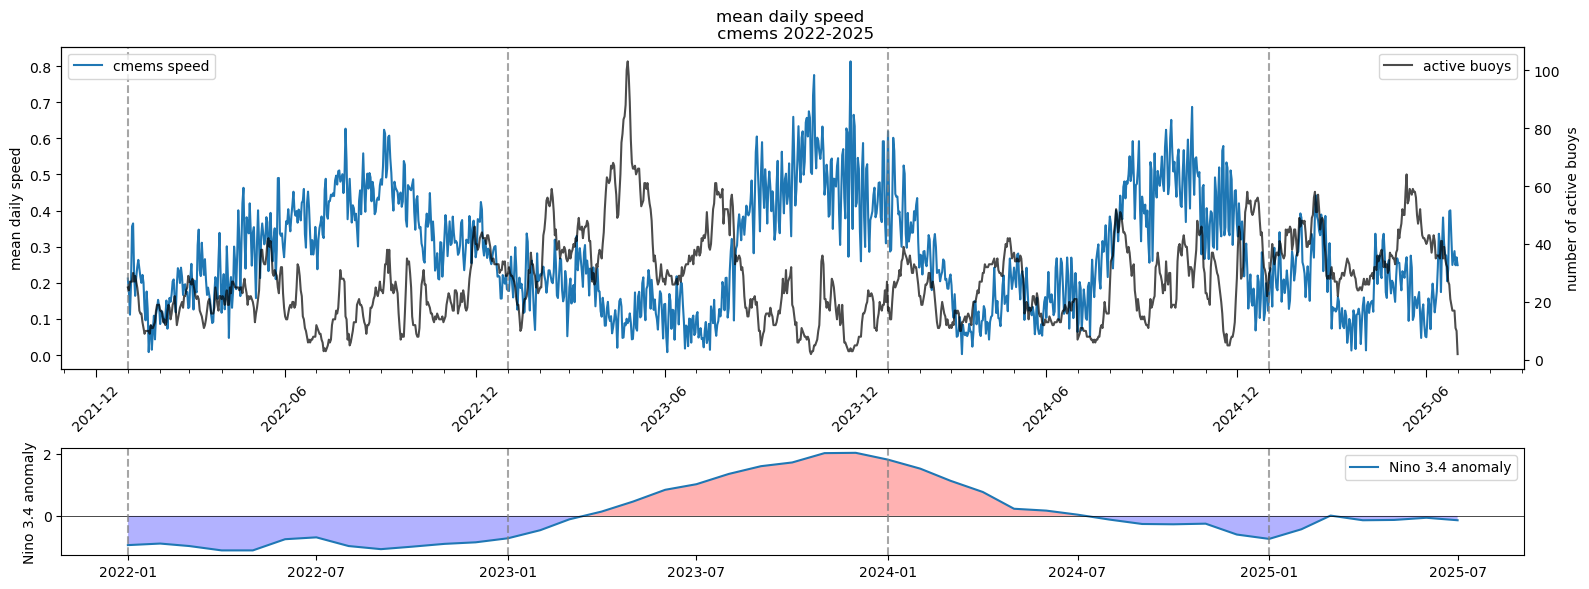

In [ ]:
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import xarray as xr 

cmems =xr.open_dataset(r"Data\cmems.nc")
nina = xr.open_dataset(r"Data\nina34.anom.nc").sel(time = slice("2022-01-01", "2025-07-01"))
cmems = cmems.sel(time = slice("2022-01-01", "2025-07-01"), depth = 15.81007  )
fig = plt.figure(figsize=(16,6))
gs = gridspec.GridSpec(2, 1, height_ratios=[3,1])

ax0 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[1,0])

speed = np.sqrt(cmems.uo.mean(dim = ["latitude", "longitude"])**2 + cmems.vo.mean(dim = ["latitude", "longitude"])**2)
ax0.plot(cmems.time, speed, label='cmems speed')
ax0.set_ylabel('mean daily speed')

ax1 = ax0.twinx()
# daily_active.index are dates – convert to datetimes so they line up with `cmems.time`
ax1.plot(pd.to_datetime(daily_active.index), daily_active,
         color='k', label='active buoys', alpha = 0.7)
ax1.set_ylabel('number of active buoys')

# add legends for both curves
ax0.legend(loc='upper left')
ax1.legend(loc='upper right')

# major ticks every 3 months with labels, minor ticks each month (no labels)
ax0.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax0.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))

ax0.tick_params(axis='x', which='major', rotation=45, length = 6)
ax0.tick_params(axis='x', which='minor', length=3)   # small ticks for months

ax0.set_ylabel("mean daily speed")
ax0.set_title("mean daily speed \n cmems 2022-2025")
#ax.set_xlim(pd.Timestamp("2023-01-01").date(),pd.Timestamp("2024-01-01").date() )
ax2.plot(nina.time, nina.value, label='Nino 3.4 anomaly')
ax2.axhline(0, color='k', lw=0.5)

# shade above/below zero
ax2.fill_between(nina.time, nina.value, 0,
                   where=nina.value >= 0,
                   facecolor='red', alpha=0.3, interpolate=True)
ax2.fill_between(nina.time, nina.value, 0,
                   where=nina.value < 0,
                   facecolor='blue', alpha=0.3, interpolate=True)

ax2.set_ylabel('Nino 3.4 anomaly')
ax2.legend()
for axi in [ax0, ax2]:
    for year in range(2022, 2026):
        axi.axvline(pd.Timestamp(f"{year}-01-01"),
                color='gray', linestyle='--', alpha=0.7)
fig.tight_layout()

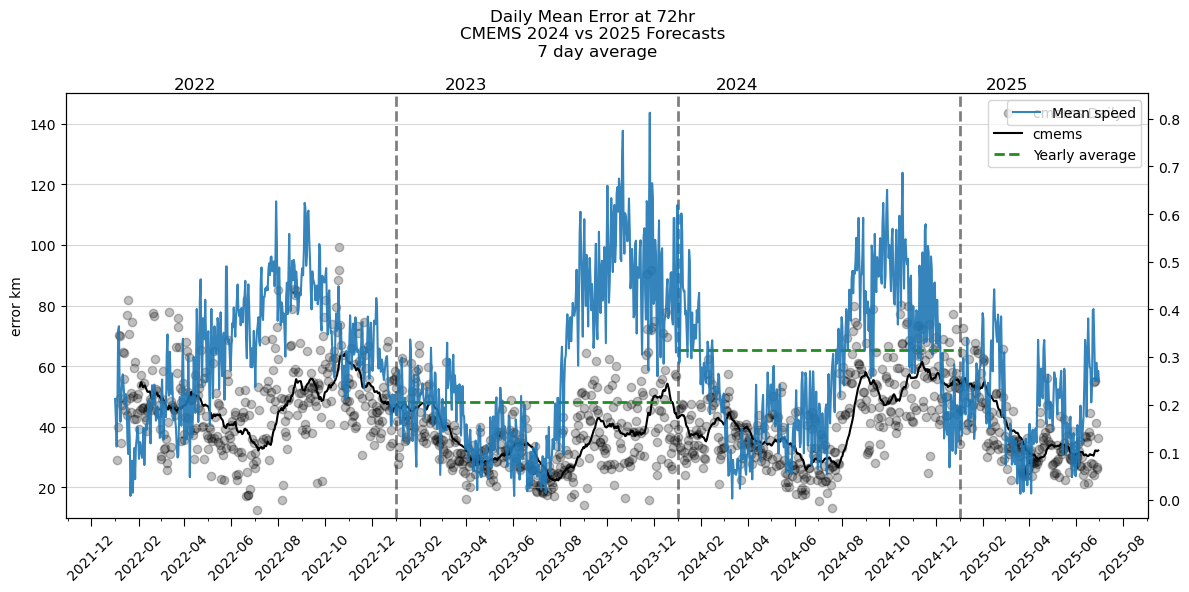

In [ ]:
cmems =xr.open_dataset(r"Data\cmems.nc")
cmems = cmems.sel(time = slice("2022-01-01", "2025-07-01"), depth = 15.81007 )
speed = np.sqrt(cmems.uo.mean(dim = ["latitude", "longitude"])**2 + cmems.vo.mean(dim = ["latitude", "longitude"])**2)
fig, ax = plt.subplots( figsize = (12,6),)
ax1 = ax.twinx()
ax1.plot(cmems.time, speed, label = 'Mean speed',zorder = 0, alpha = 0.90 )
#ax1.set_ylim(-0.5, 1)
#CMEMS
ax.scatter(fctscomb.Day, fctscomb.error_km, color = "k", alpha = 0.25, label = "cmems Daily")
ax.plot(fctscomb.Day, fctscomb["rolling"], color = "k", label = "cmems")
#OSCAR 
# ax.scatter(fcts2.Day, fcts2.error_km, color = "chocolate", alpha = 0.25 ,label = "OSCAR Daily")
# ax.plot(fcts2.Day, fcts2["rolling"], color = "red", label = "OSCAR")
#NO Forecast
#ax.scatter(fcts3.Day, fcts3.error_km, color = "g", alpha = 0.25 ,label = "OSCAR Daily")
# ax[0].plot(fcts5.Day, fcts5["rolling"], color = "gray", label = "No Forecast", linestyle = "--")
# ax[1].plot(fcts3.Day, fcts3["rolling"], color = "gray", label = "No Forecast", linestyle = "--")

ax1.legend()

fig.suptitle("Daily Mean Error at 72hr \nCMEMS 2024 vs 2025 Forecasts \n 7 day average")
ax.set_ylabel("error km")
#ax.set_title("20232024")
ax.text(0.1, 1.01, '2022',  transform=ax.transAxes, fontsize = 12)
ax.text(0.35, 1.01, '2023', transform=ax.transAxes, fontsize = 12)
ax.text(0.6, 1.01, '2024',  transform=ax.transAxes, fontsize = 12)
ax.text(0.85, 1.01, '2025', transform=ax.transAxes, fontsize = 12)
ax.grid(axis='y', alpha=0.5)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
ax.tick_params(axis='x', which='major', rotation=45, length = 6)
ax.vlines([pd.Timestamp("2023-01-01").date()], 0, 150, color = "k", lw = 2, ls = "--", alpha = 0.5)
ax.vlines([pd.Timestamp("2024-01-01").date()], 0, 150, color = "k", lw = 2, ls = "--", alpha = 0.5)
ax.vlines([pd.Timestamp("2025-01-01").date()], 0, 150, color = "k", lw = 2, ls = "--", alpha = 0.5)
ax.hlines(48.3, pd.Timestamp("2023-01-01").date(), pd.Timestamp("2024-01-01").date(),color = 'forestgreen', lw = 2, ls= "--")
ax.hlines(65.3, pd.Timestamp("2024-01-01").date(), pd.Timestamp("2025-01-01").date(), label = "Yearly average", color = "forestgreen", lw = 2, ls= "--")
ax.set_ylim(10, 150)
ax.legend()
fig.tight_layout()


##### Mounthly errors

In [ ]:
mergedall = pd.concat([merged02, merged03, merged04, merged05])



seasonbin = np.arange(0,13,3)
merged02['month'] = merged02.Time.dt.month
merged02["seasonbin"] = pd.cut(merged02["month"], seasonbin)

merged03['month'] = merged03.Time.dt.month
merged03["seasonbin"] = pd.cut(merged03["month"], seasonbin)

merged04['month'] = merged04.Time.dt.month
merged04["seasonbin"] = pd.cut(merged04['month'], seasonbin)

merged05['month'] = merged05.Time.dt.month
merged05["seasonbin"] = pd.cut(merged05['month'], seasonbin)

merged02['lead_bins'] = pd.cut(merged02['leadtime'], bins)
merged03['lead_bins'] = pd.cut(merged03['leadtime'], bins)
merged04['lead_bins'] = pd.cut(merged04['leadtime'], bins)
merged05['lead_bins'] = pd.cut(merged05['leadtime'], bins)

a= binlist[18]
print(a)
fclt =  merged02.groupby('lead_bins', observed= False).get_group(a).copy() 
fc4lt = merged03.groupby('lead_bins', observed= False).get_group(a).copy()
fc6lt = merged04.groupby('lead_bins', observed= False).get_group(a).copy()    
fc8lt = merged05.groupby('lead_bins', observed= False).get_group(a).copy()    

monthly2025 = fc8lt.groupby("month", observed= False)["error_km"].mean()
monthly2024 = fclt.groupby("month", observed= False)["error_km"].mean()
monthly2023 = fc4lt.groupby("month",observed= False)["error_km"].mean()
monthly2022 = fc6lt.groupby("month",observed= False)["error_km"].mean()

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", 'Nov', 'Dec']
season2025 = fc8lt.groupby("seasonbin",observed= False)['error_km'].mean()
season2024 = fclt.groupby("seasonbin",observed= False)['error_km'].mean()
season2023 = fc4lt.groupby("seasonbin",observed= False)['error_km'].mean()
season2022 = fc6lt.groupby("seasonbin",observed= False)['error_km'].mean()
seasons = ["Jan-Mar", 'Apr-Jun', 'Jul-Sep', 'Oct-Dec']

(68.0, 72.0]


In [ ]:
## lets look at just variance of dFAD speeds themselves
long = longlist.copy()
long['day'] = pd.to_datetime(long.Time.dt.date)
def calc_var(group):
    return group.x_speed.var() + group.y_speed.var()
varts = long.groupby('day', observed = False).apply(calc_var, include_groups=False).reset_index(name = 'var')
varts = varts.rename(columns = {'day': 'startday'})

In [ ]:
print(season2025.fillna(0))

seasonbin
(0, 3]     43.527591
(3, 6]     32.088796
(6, 9]      0.000000
(9, 12]     0.000000
Name: error_km, dtype: float64


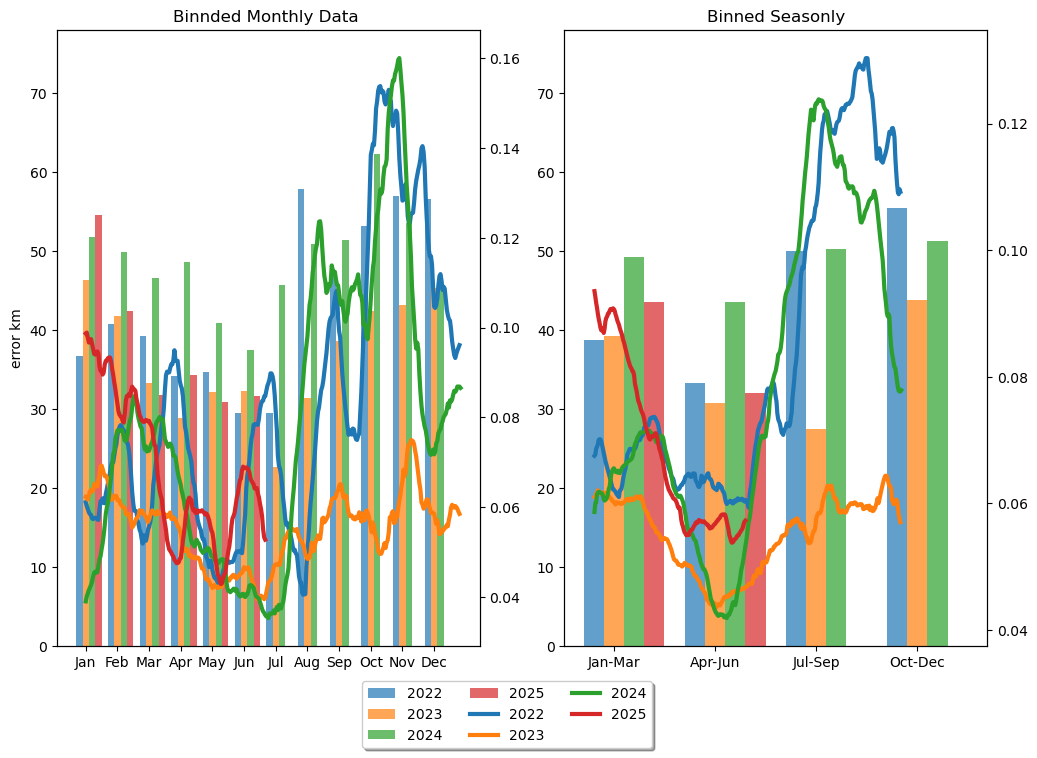

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (12,8))
width = 0.2
x1 = np.arange(1,13,1)
x2 = np.arange(1+width,13+width, 1)
x3 = np.arange(1+width*2,13+width*2, 1)
x4 = np.arange(1+width*3,13+width*3, 1)
ax[0].bar(x1, monthly2022,width = width ,label = "2022", alpha =0.7)
ax[0].bar(x2,monthly2023,width = width , label = "2023", alpha =0.7)
ax[0].bar(x3,monthly2024,width = width , label = "2024", alpha =0.7)
ax[0].bar(x4[:6],monthly2025,width = width , label = "2025", alpha =0.7)
ax[0].set_ylabel("error km")
ax[0].set_title("Binnded Monthly Data ")
ax[0].set_xticks(x1+width, months)
x4 = np.arange(1,5,1)
x5 = np.arange(1+width,5+width,1)
x6 = np.arange(1+width*2,5+width*2,1) 
x7 = np.arange(1+width*3,5+width*3,1) 
ax[1].bar(x4, season2022,width = width, alpha = 0.7, )
ax[1].bar(x5, season2023,width = width, alpha = 0.7, )
ax[1].bar(x6, season2024,width = width, alpha = 0.7, )
ax[1].bar(x7, season2025.fillna(0),width = width, alpha = 0.7, )
#ax[1].hlines(season2022,x4-0.5, x4+0.5)
ax[1].set_xticks(x4+width, seasons)
ax[1].set_title("Binned Seasonly")
for axs in [ax[1], ax[0]]:
    axs.set_ylim(0,78)

ax0 = ax[0].twinx()
ax1 = ax[1].twinx()

merged_var = varts
y22 = merged_var[merged_var.startday < pd.Timestamp('2023-01-01')].copy()
y22 = y22[y22.startday > pd.Timestamp('2022-01-01')].copy()
y23 = merged_var[merged_var.startday < pd.Timestamp('2024-01-01')].copy()
y23 = y23[y23.startday > pd.Timestamp('2023-01-01')].copy()
y24 = merged_var[merged_var.startday > pd.Timestamp('2024-01-01')].copy()
y24 = y24[y24.startday < pd.Timestamp('2025-01-01')].copy()
y25 = merged_var[(merged_var.startday > pd.Timestamp('2025-01-01')) & (merged_var.startday < pd.Timestamp('2025-07-01'))]
years = [y22, y23, y24, y25]
startdates = pd.to_datetime(['2022-01-01', '2023-01-01', '2024-01-01', '2025-01-01'])

for i,y  in enumerate(years):
    y = y.copy()
    y["startday"] = pd.to_datetime(y["startday"])
    y["julianday"] = (y["startday"] - startdates[i]).dt.days
    y = y.sort_values("startday").reset_index(drop=True)
    y["var7day"] = y["var"].rolling(30, 20, center=True).mean()
    y["var90day"] = y["var"].rolling(90, 20, center=True).mean()

    ax0.plot(y["julianday"]/30 +1,   y["var7day"],  label=startdates[i].year, lw = 3)
    ax1.plot(y["julianday"]/30/4+1 , y["var90day"], lw = 3)

    if i == 0:
        month_starts = pd.date_range("2023-01-01", "2023-12-01", freq="MS")
        month_ticks = (month_starts - pd.Timestamp("2023-01-01")).days
        month_labels = month_starts.strftime("%b")





fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.075),
          fancybox=True, shadow=True, ncol=3)

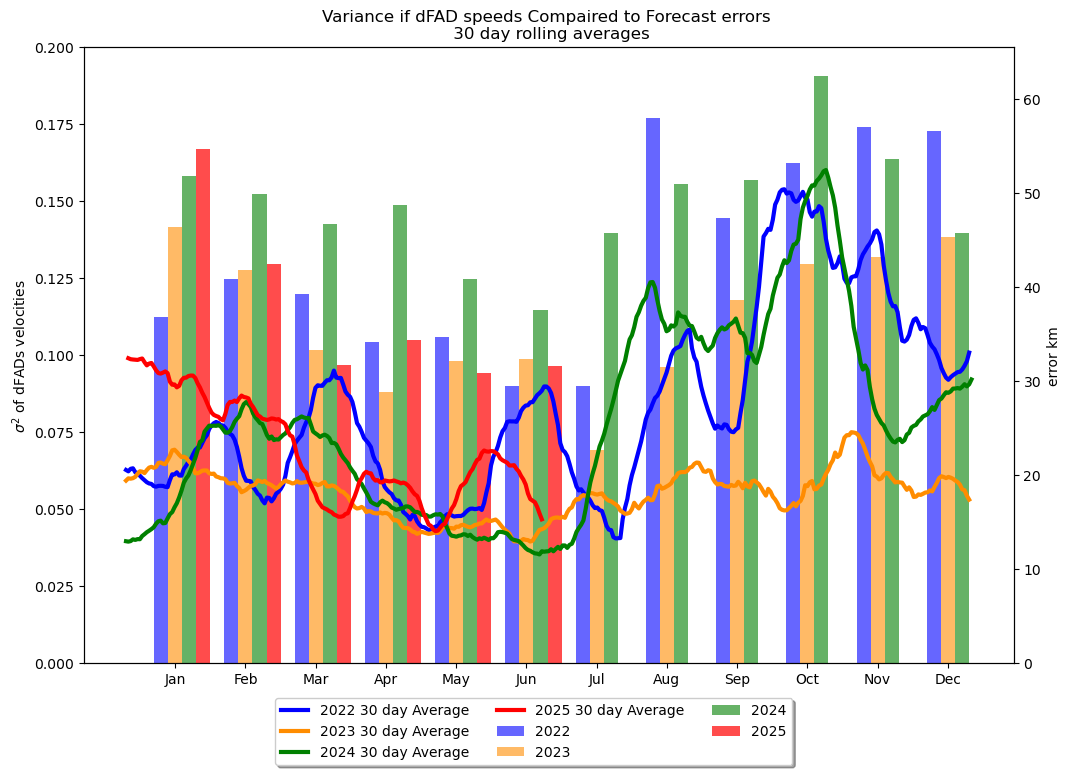

In [ ]:
fig, ax0 = plt.subplots( figsize = (12,8))
ax = ax0.twinx()
width = 0.2
x1 = np.arange(1,13,1)
x2 = np.arange(1+width,13+width, 1)
x3 = np.arange(1+width*2,13+width*2, 1)
x4 = np.arange(1+width*3,13+width*3, 1)
colors = ['b', 'darkorange', 'green', 'r']

ax.bar(x1, monthly2022,width = width ,label = "2022", alpha =0.6, color = colors[0])
ax.bar(x2,monthly2023,width = width , label = "2023", alpha =0.6, color = colors[1])
ax.bar(x3,monthly2024,width = width , label = "2024", alpha =0.6, color = colors[2])
ax.bar(x4[:6],monthly2025,width = width , label = "2025", alpha =0.7, color = colors[3])
ax.set_ylabel("error km")
ax.set_title('Variance if dFAD speeds Compaired to Forecast errors \n 30 day rolling averages')
ax.set_xticks(x1+width, months)


merged_var = mergedall.drop_duplicates(subset= ['startday'], keep ='first')
merged_var = varts
y22 = merged_var[merged_var.startday <= pd.Timestamp('2023-01-01')].copy()
y22 = y22[y22.startday >= pd.Timestamp('2022-01-01')].copy()
y23 = merged_var[merged_var.startday <= pd.Timestamp('2024-01-01')].copy()
y23 = y23[y23.startday >= pd.Timestamp('2023-01-01')].copy()
y24 = merged_var[merged_var.startday >= pd.Timestamp('2024-01-01')].copy()
y24 = y24[y24.startday <= pd.Timestamp('2025-01-01')].copy()
years = [y22, y23, y24,y25]
startdates = pd.to_datetime(['2022-01-01', '2023-01-01', '2024-01-01', '2025-01-01'])

for i,y  in enumerate(years):
    y = y.copy()
    y["startday"] = pd.to_datetime(y["startday"])
    y["julianday"] = (y["startday"] - startdates[i]).dt.days
    y = y.sort_values("startday").reset_index(drop=True)
    y["var30day"] = y["var"].rolling(30, 1, center=True).mean()
    y["var90day"] = y["var"].rolling(90, 20, center=True).mean()

    ax0.plot(y["julianday"]/30.41+0.5,   y["var30day"],  label= f"{startdates[i].year} 30 day Average", lw = 3, color = colors[i], zorder = 10)

    if i == 0:
        month_starts = pd.date_range("2023-01-01", "2023-12-01", freq="MS")
        month_ticks = (month_starts - pd.Timestamp("2023-01-01")).days
        month_labels = month_starts.strftime("%b")


ax0.set_zorder(ax.get_zorder() + 1)  # Put ax1 in front of ax2
ax0.patch.set_visible(False)
ax0.set_ylim(0,0.2)
ax0.set_ylabel(r'$\sigma^2$ of dFADs velocities')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.075),
          fancybox=True, shadow=True, ncol=3)

<>:57: SyntaxWarning: invalid escape sequence '\s'
<>:57: SyntaxWarning: invalid escape sequence '\s'
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_23652\4164049877.py:57: SyntaxWarning: invalid escape sequence '\s'
  fig.supylabel('Daily dFAD variance $\sigma^2$')


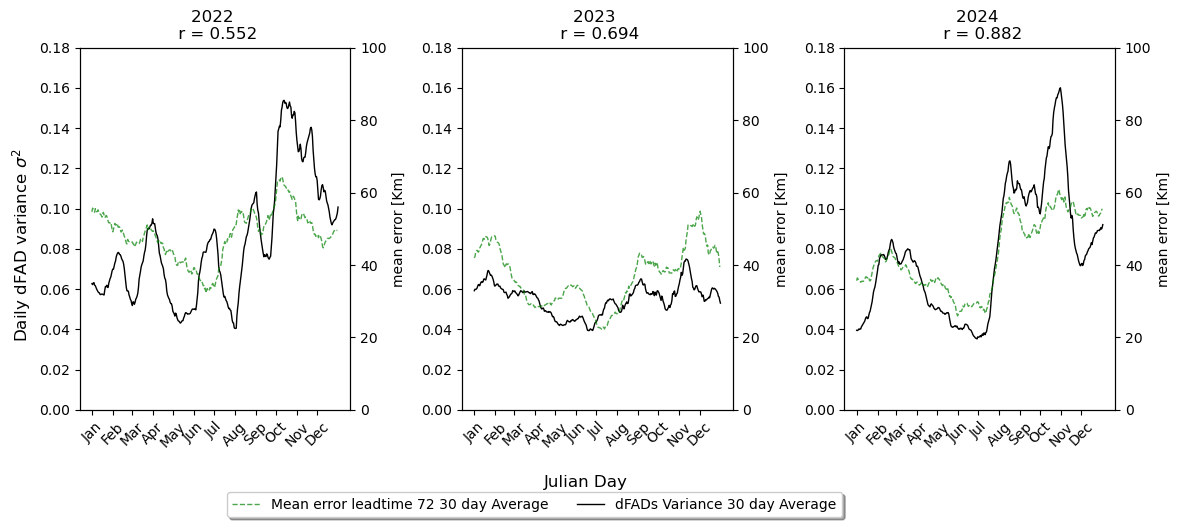

In [ ]:
## changing the above plot to both line plots. need 30 day rolling average of means 
fig, axs =plt.subplots(1,3, figsize = (12,5))
ax0, ax1, ax2 = axs
years = [y22, y23, y24]
vars_year = []
startdates = pd.to_datetime(['2021-12-31', '2022-12-31', '2023-12-31'])
for i,y  in enumerate(years):
    y = y.copy()
    y["startday"] = pd.to_datetime(y["startday"])
    y["julianday"] = (y["startday"] - startdates[i]).dt.days
    y = y.sort_values("startday").reset_index(drop=True)
    y["var30day"] = y["var"].rolling(30, 1, center=True).mean()
    y["var90day"] = y["var"].rolling(90, 20, center=True).mean()
    axs[i].plot(y["julianday"],   y["var30day"],  label= f"dFADs Variance 30 day Average", lw = 1, color = 'k', zorder = 10)
    axs[i].set(ylim = [0,0.18],)
    vars_year.append(y)
    
# years 2022,2023,2024
lts = [fclt,fc4lt,fc6lt]
tss = []
for i,lt  in enumerate(lts):
    axi = axs[i].twinx()
    lt = lt.copy()
    lt['starttime'] = lt['Time'] - pd.to_timedelta(lt['leadtime'], unit = 'hours')
    lt["starttime"] = pd.to_datetime(lt["starttime"])
    lt["julianday"] = (lt["starttime"] - startdates[i]).dt.days
    lt = lt.sort_values("starttime").reset_index(drop=True)
    lt = lt.groupby('julianday', observed= False)['error_km'].mean()
    lt = lt.to_frame(name = 'error_km').reset_index()
    lt["error_km30"] = lt["error_km"].rolling(30, 1, center=True).mean()
    lt["error_km90"] = lt["error_km"].rolling(90, 20, center=True).mean()
    axi.plot(lt["julianday"],   lt["error_km30"],  label= f"Mean error leadtime 72 30 day Average", lw = 1, color = 'g', zorder = 10, ls = '--', alpha = 0.7)
    axi.set(ylim = [0,100], ylabel = 'mean error [Km]')
    tss.append(lt)


fig.supxlabel('Julian Day')
corrs = []
 
for i in range(len(tss)):
    ts = tss[i]
    var = vars_year[i]
    var = var.set_index('julianday')
    ts= ts.set_index('julianday')
    var = var.reindex(ts.index)
    corrs.append(np.corrcoef(var['var30day'], ts['error_km30'])[0,1])

ax0.set_title(f"2022 \n r = {corrs[0]:.3f}")
ax1.set_title(f"2023 \n r = {corrs[1]:.3f}")
ax2.set_title(f"2024 \n r = {corrs[2]:.3f}")
handles, labels = axi.get_legend_handles_labels()
for axi in axs: 
    axi.set_xticks([1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335])
    axi.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
    axi.tick_params(axis='x', labelrotation=45)

fig.supylabel('Daily dFAD variance $\sigma^2$')
handles2, labels2 = axs[i].get_legend_handles_labels()
handles.extend(handles2)
labels.extend(labels2)
by_label = dict(zip(labels, handles))  # removes duplicates
fig.legend(by_label.values(), by_label.keys(), loc='upper center', bbox_to_anchor=(3.2/7, 0.02), fancybox=True, shadow=True, ncol=3)

fig.tight_layout()

In [ ]:
cmems = xr.open_dataset(r'Data\cmems_monthly.nc')
cmems2023 = cmems.sel(time = slice("2023-01-01", "2024-01-01"), depth = 13.46714)
cmems2024 = cmems.sel(time = slice("2024-01-01", "2025-01-01"), depth = 13.46714)
cmems2022 = cmems.sel(time = slice("2022-01-01", "2023-01-01"), depth = 13.46714)

<>:74: SyntaxWarning: invalid escape sequence '\s'
<>:77: SyntaxWarning: invalid escape sequence '\s'
<>:74: SyntaxWarning: invalid escape sequence '\s'
<>:77: SyntaxWarning: invalid escape sequence '\s'
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_23652\608292444.py:74: SyntaxWarning: invalid escape sequence '\s'
  ax0.plot(varts.startday, varts.var30day , label = f'Daily mean $\sigma^2$')
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_23652\608292444.py:77: SyntaxWarning: invalid escape sequence '\s'
  ax0.set(ylabel = f'$\sigma ^2$',xlim = [pd.Timestamp('2022-01-01'), pd.Timestamp('2026-01-01')])


[4.5 5.  5.5 6.  6.5 7.  7.5 8. ]


Text(0.5, 0.98, 'Yearly Variations in Currents and Errors')

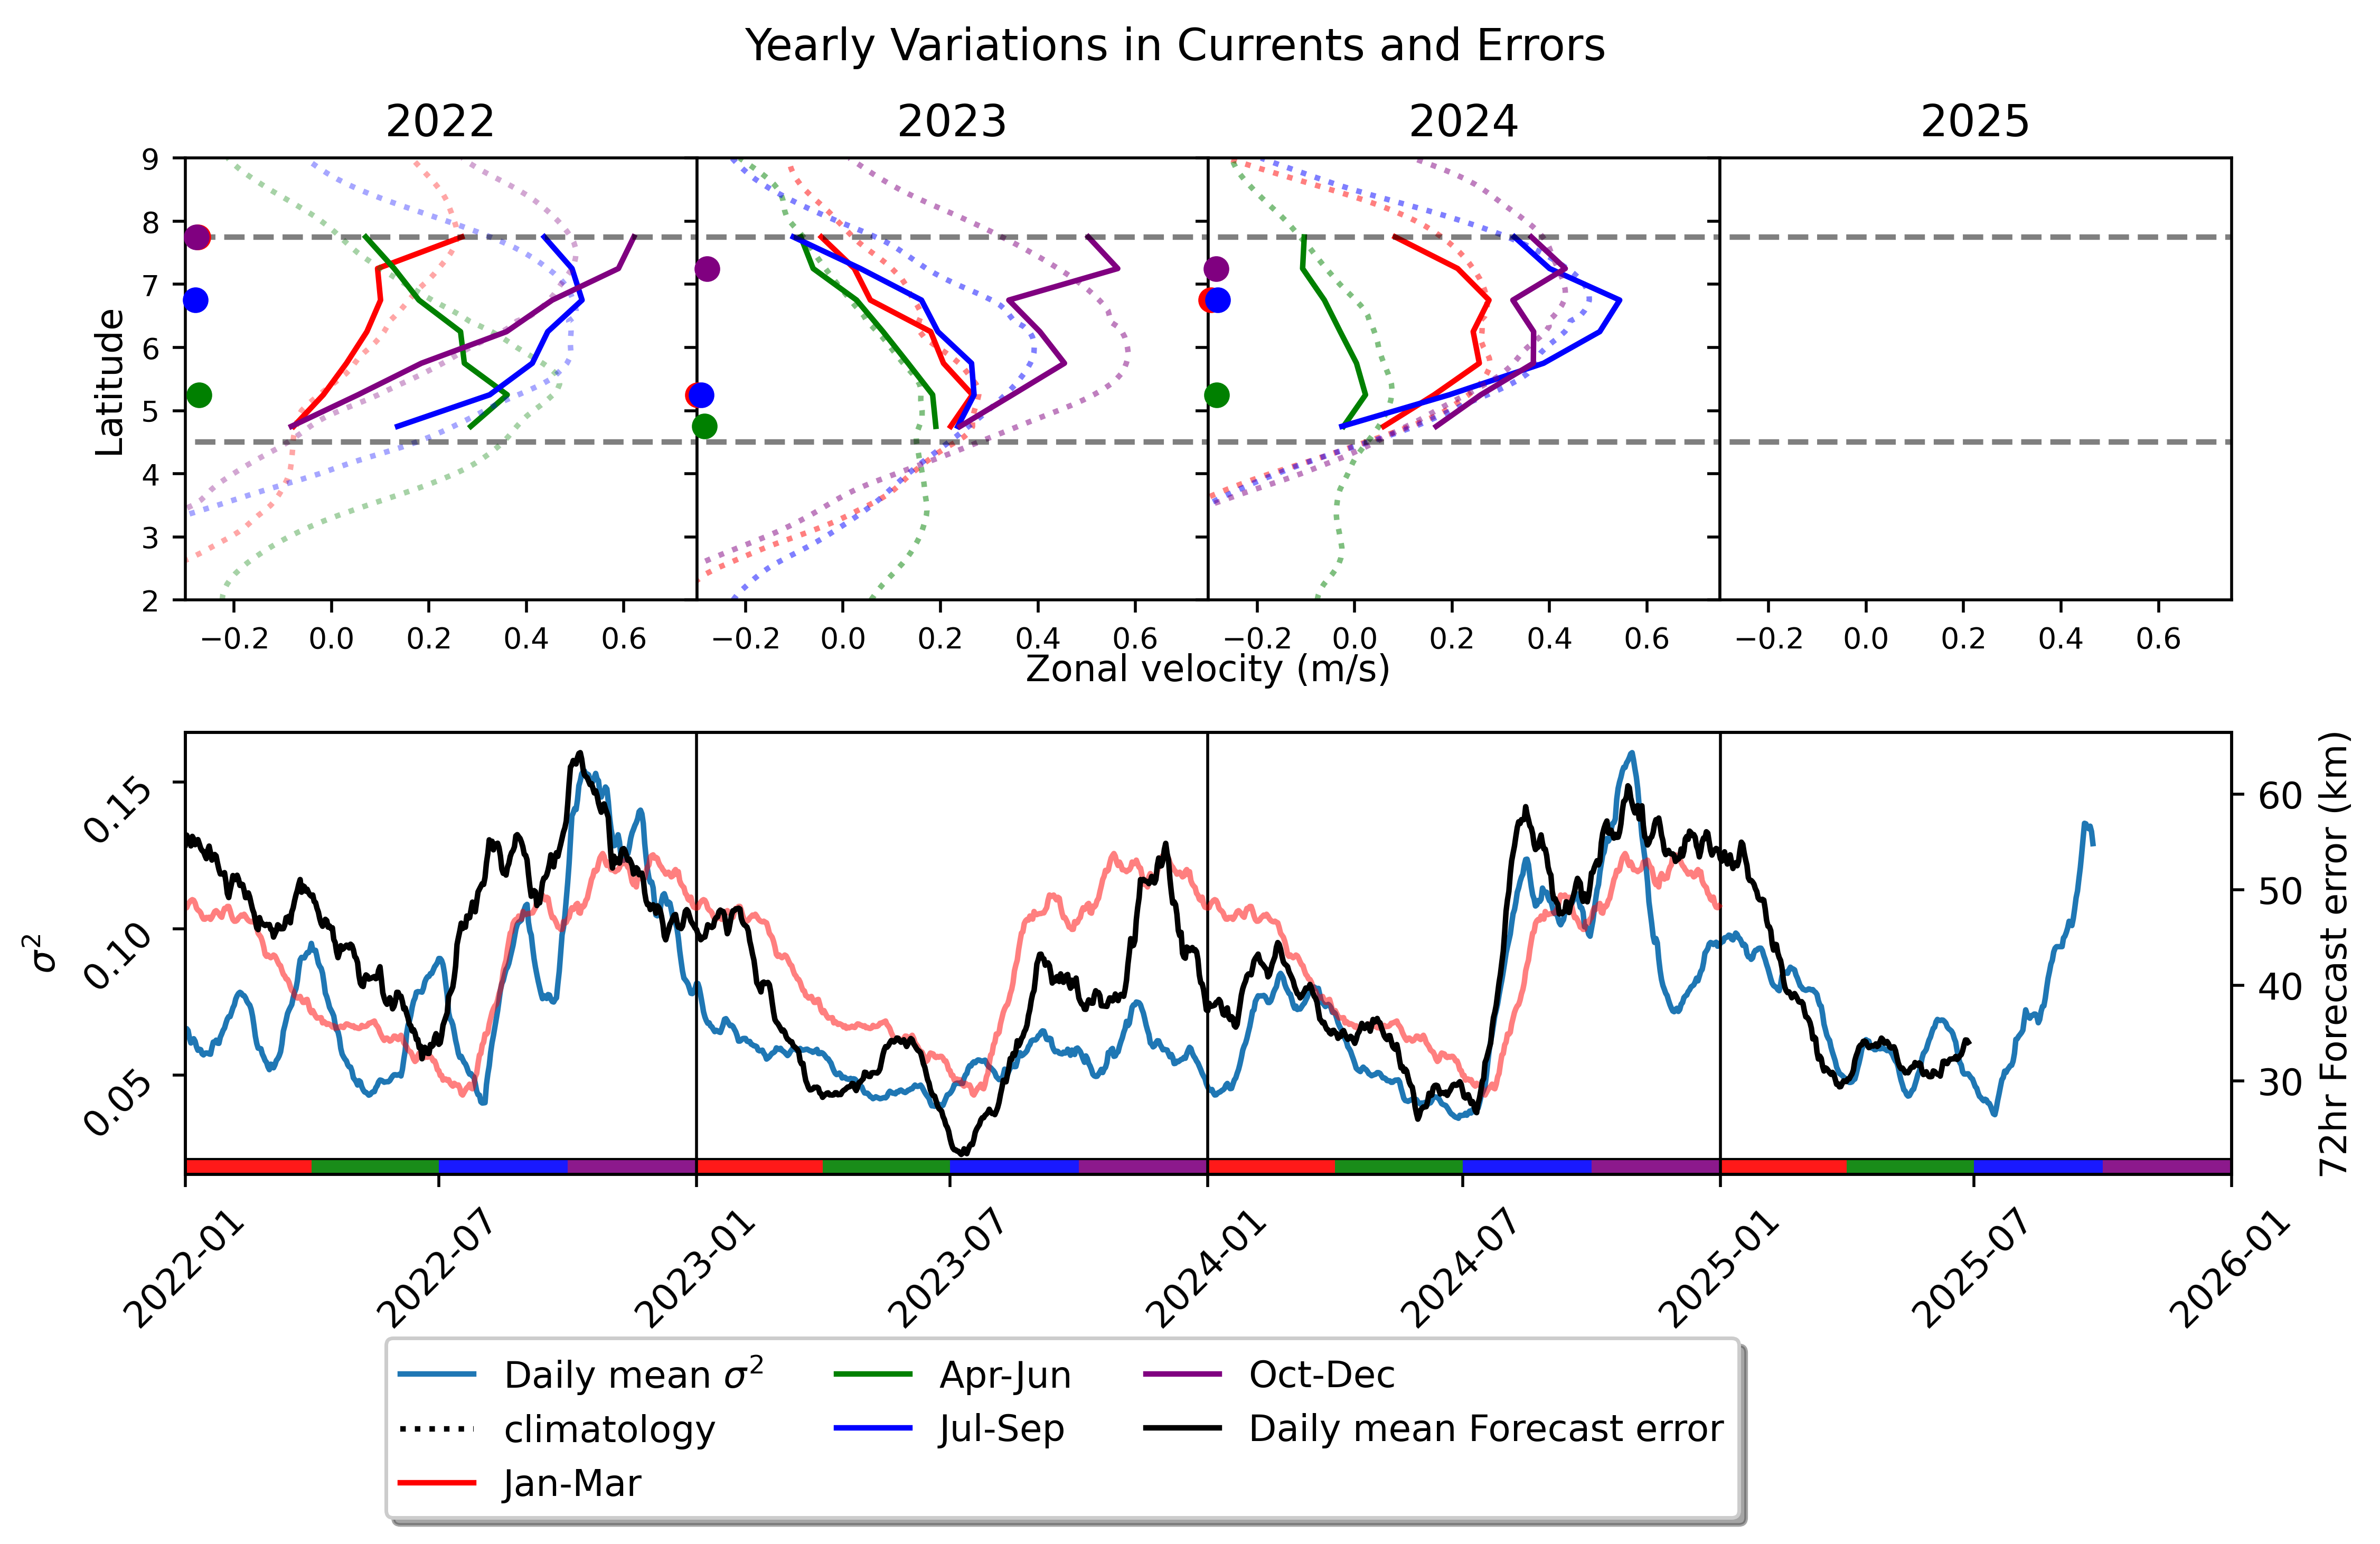

In [ ]:
### recreating the figure above  to be in one time series with profiles for each year plotted below
from matplotlib.gridspec import GridSpec
# loading data
fclt =  merged.groupby('lead_bins', observed= False).get_group(a).copy() 
fclt_daily = fclt.groupby('startday', observed= False)['error_km'].mean()
fclt_daily = fclt_daily.to_frame(name ='error_km').reset_index()
fclt_daily['error30day'] = fclt_daily['error_km'].rolling(30,1,center = True).mean()

fclt_daily['starttime'] = pd.to_datetime(fclt_daily.startday)
fclt_daily['month'] = fclt_daily.starttime.dt.month
fclt_daily['day'] = fclt_daily.starttime.dt.day

clime = fclt_daily.groupby(['month', 'day'])['error_km'].mean()
clime = clime.reset_index()
clime = pd.concat([clime.iloc[-30:], clime, clime.iloc[:30]])
clime['error30day'] = clime['error_km'].rolling(30,0).mean()
clime = clime.reset_index(drop = True)
clime = clime.iloc[30:-30]
clime = pd.concat([clime.iloc[:-1], clime.iloc[:-1], clime], ignore_index= True)
clime['startday'] = pd.date_range('2022-01-01', '2024-12-31', freq= pd.Timedelta(1, 'day'))

varts['var30day'] = varts['var'].rolling(30,10, center = True).mean()
varts['var90day'] = varts['var'].rolling(90,10, center = True).mean()

upperlat = 10
box = cmems2022.sel(latitude = slice(2, upperlat), longitude = slice(-163.75, -160.5))
box = box.mean(dim = "longitude")
box2 =cmems2023.sel(latitude = slice(2,upperlat), longitude = slice(-163.74, -160.5))
box2 = box2.mean(dim = "longitude")
box3 =cmems2024.sel(latitude = slice(2,upperlat), longitude = slice(-163.74, -160.5))
box3 = box3.mean(dim = "longitude")

#Calc Poofiles
 
def calc_lat_average(longlist):
    profiles = pd.DataFrame()
    for n, bin in enumerate(longlist.season.unique().dropna().sort_values()):
        season = longlist[longlist['season'] == bin]
        profile =season.groupby('lat_bin', observed=False)['x_speed'].mean()
        profiles[n+1] = profile
    profiles = profiles.reset_index()
    profiles['lat'] = lat_bins[profiles.index] + np.diff(lat_bins)/2
    return profiles

longlist['year'] = longlist.Time.dt.year
longlist['month'] = longlist.Time.dt.month
month_bins = np.array([1,4,7,10,13])
longlist['season'] = pd.cut(longlist['month'], month_bins, right = False) # makes it [a,b) months 1-3, 4-6,7-9, 10-12
lat_bins = np.arange(4.5,8.01, 0.50)
print(lat_bins)
longlist['lat_bin'] = pd.cut(longlist.lats, lat_bins, right = False)

longlist2022 = longlist[longlist['year'] == 2022]
longlist2023 = longlist[longlist['year'] == 2023]
longlist2024 = longlist[longlist['year'] == 2024]
longlist2025 = longlist[longlist['year'] == 2025]

profiles2022 = calc_lat_average(longlist2022)
profiles2023 = calc_lat_average(longlist2023)
profiles2024 = calc_lat_average(longlist2024)
profiles2025 = calc_lat_average(longlist2025)

fig= plt.figure(figsize=(10,5), dpi=500)
gs = GridSpec(2,4)
ax0 = fig.add_subplot( gs[1,:])
ax22 = fig.add_subplot(gs[0,0])
ax23 = fig.add_subplot(gs[0,1])
ax24 = fig.add_subplot(gs[0,2])
ax25 = fig.add_subplot(gs[0,3])



ax0b = ax0.twinx()
ax0.plot(varts.startday, varts.var30day , label = f'Daily mean $\sigma^2$')
ax0b.plot(fclt_daily.startday, fclt_daily.error30day, color = 'k', label = 'Daily mean Forecast error')
ax0b.plot(clime.startday, clime.error30day, color ='r', zorder = 1, alpha = 0.5)
ax0.set(ylabel = f'$\sigma ^2$',xlim = [pd.Timestamp('2022-01-01'), pd.Timestamp('2026-01-01')])
ax0.tick_params(labelrotation = 45)
for d in pd.to_datetime(['2022-01-01', '2023-01-01', '2024-01-01', '2025-01-01']):
    ax0.axvline(d, color='k', lw=0.8)
ax0b.set_ylabel('72hr Forecast error (km)')
#x0.set_xticks(['2024'], )

# Add corrilations to the plots. 

# seasonal color strip on ax0 (acts as key for lower-panel colors)
season_colors = ['r', 'g', 'b', 'purple']  # Jan-Mar, Apr-Jun, Jul-Sep, Oct-Dec
xmin, xmax = pd.Timestamp('2022-01-01'), pd.Timestamp('2026-01-01')

for yr in range(2022, 2026):
    season_edges = [
        (pd.Timestamp(f'{yr}-01-01'), pd.Timestamp(f'{yr}-04-01'), season_colors[0]),
        (pd.Timestamp(f'{yr}-04-01'), pd.Timestamp(f'{yr}-07-01'), season_colors[1]),
        (pd.Timestamp(f'{yr}-07-01'), pd.Timestamp(f'{yr}-10-01'), season_colors[2]),
        (pd.Timestamp(f'{yr}-10-01'), pd.Timestamp(f'{yr+1}-01-01'), season_colors[3]),
    ]
    for s, e, c in season_edges:
        s_clip, e_clip = max(s, xmin), min(e, xmax)
        if s_clip < e_clip:
            ax0.axvspan(s_clip, e_clip, ymin=0.00, ymax=0.035, color=c, alpha=0.9, ec='none')

# optional thin border above the strip
ax0.plot([xmin, xmax], [0.035, 0.035], transform=ax0.get_xaxis_transform(), color='k', lw=0.6)

labels = ['Jan-Mar', 'Apr-Jun', 'Jul-Sep', 'Oct-Dec']
colors = ['r', 'g', 'b', 'purple']
for i in range(4): 
    ax22.plot(profiles2022[i+1], profiles2022.lat, label = labels[i], color = colors[i])
    ax23.plot(profiles2023[i+1], profiles2023.lat, color = colors[i])
    ax24.plot(profiles2024[i+1], profiles2024.lat, color = colors[i])
    ax22.scatter(-0.3+np.random.random(1)*0.03,profiles2022.iloc[profiles2022[i+1].idxmax()].lat,
     color = colors[i], marker = "o", clip_on = False, zorder = 100)
    ax23.scatter(-0.3+np.random.random(1)*0.03,profiles2023.iloc[profiles2023[i+1].idxmax()].lat,
     color = colors[i], marker = "o", clip_on = False, zorder = 100)
    ax24.scatter(-0.3+np.random.random(1)*0.03,profiles2024.iloc[profiles2024[i+1].idxmax()].lat,
     color = colors[i], marker = "o", clip_on = False, zorder = 100)
    #CMEMS
    ax22.plot(box.uo[i*3:(i+1)*3,:].mean(dim = "time"), box.latitude, color = colors[i], alpha = 0.35, ls = ':') #f"{1+i*3} - {(i+1)*3}
    ax23.plot(box2.uo[i*3:(i+1)*3,:].mean(dim = "time"), box2.latitude, color = colors[i], alpha = 0.5, ls = ':')
    ax24.plot(box3.uo[i*3:(i+1)*3,:].mean(dim = "time"), box2.latitude, color = colors[i], alpha = 0.5, ls = ':')

ax22.set_ylabel('Latitude')

yearlabels = ['2022', '2023', '2024', '2025']
for i, axi in enumerate([ax22, ax23,ax24,ax25]):
    axi.set(xlim = [-0.3, 0.75], ylim = [2, 9], title= yearlabels[i])
    axi.tick_params(axis='both', labelsize=8)
    axi.hlines([7.75,4.5], xmin = -0.4, xmax = 7.5, color = 'k', alpha = 0.5, ls = '--')
    axi.set_xticks([-0.2,0,0.2,0.4, 0.6])

# Remove gaps between lower subplots and make them share y-axis appearance
for axi in [ax23, ax24, ax25]:
    axi.set_yticklabels([])
    axi.set_ylabel('')

# Adjust the GridSpec to remove horizontal spacing between lower plots
gs.update(wspace=0, hspace=0.3)
    # ax25.plot(profiles2025[i+1], profiles2025.lat)

ax0.plot([], [], c='k', ls=':', label='climatology')
fig.legend(loc='upper center', bbox_to_anchor=(3.2/7, 0.0),
          fancybox=True, shadow=True, ncol=3)
        # shared x-label for the top-row profile panels
top_axes = [ax22, ax23, ax24, ax25]
x_center = (min(ax.get_position().x0 for ax in top_axes) + max(ax.get_position().x1 for ax in top_axes)) / 2
y_text = max(min(ax.get_position().y0 for ax in top_axes) - 0.04, 0.01)

fig.text(x_center, y_text, r'Zonal velocity (m/s)', ha='center', va='top')
fig.suptitle(r'Yearly Variations in Currents and Errors')

In [ ]:
## Calcuate Climatology of errors, show that its actually lower throuhgout the entire year
fclt_daily2022 = fclt_daily[(fclt_daily.startday >= pd.to_datetime('2022-01-01').date()) & (fclt_daily.startday < pd.to_datetime('2023-01-01').date()) ].copy()
fclt_daily2023 = fclt_daily[(fclt_daily.startday >= pd.to_datetime('2023-01-01').date()) & (fclt_daily.startday < pd.to_datetime('2024-01-01').date()) ].copy()
fclt_daily2024 = fclt_daily[(fclt_daily.startday >= pd.to_datetime('2024-01-01').date()) & (fclt_daily.startday < pd.to_datetime('2025-01-01').date()) ].copy()

fclt_daily2022['julian_day'] = (fclt_daily2022.startday - pd.to_datetime('2022-01-01').date() + pd.Timedelta(1, 'days'))/pd.Timedelta(1, 'days')
fclt_daily2023['julian_day'] = (fclt_daily2023.startday - pd.to_datetime('2023-01-01').date() + pd.Timedelta(1, 'days'))/pd.Timedelta(1, 'days')
fclt_daily2024['julian_day'] = (fclt_daily2024.startday - pd.to_datetime('2024-01-01').date() + pd.Timedelta(1, 'days'))/pd.Timedelta(1, 'days')

fclt_daily2022 = fclt_daily2022.set_index('julian_day')
fclt_daily2023 = fclt_daily2023.set_index('julian_day')
fclt_daily2024 = fclt_daily2024.set_index('julian_day')

clim = pd.merge(fclt_daily2022, fclt_daily2023, 'outer', on = 'julian_day', suffixes= ['_2022', '_2023'] )
clim  = pd.merge(clim, fclt_daily2024, 'outer', on = 'julian_day')
# clim = clim[['error_km_2022']]
# def clim_mean_error(row): 
#     row['mean_error'] = row['error_km_2022']
# clim = clim.apply()

In [ ]:
fclt_daily['starttime'] = pd.to_datetime(fclt_daily.startday)
fclt_daily['month'] = fclt_daily.starttime.dt.month
fclt_daily['day'] = fclt_daily.starttime.dt.day

clime = fclt_daily.groupby(['month', 'day'])['error30day'].mean()
clime = clime.reset_index()
clime = pd.concat([clime.iloc[:-1], clime.iloc[:-1], clime], ignore_index= True)
clime['startday'] = pd.date_range('2022-01-01', '2024-12-31', freq= pd.Timedelta(1, 'day'))
clime

,month,day,error30day,startday
0,1,1,47.771279,2022-01-01
1,1,2,48.033821,2022-01-02
2,1,3,47.924867,2022-01-03
3,1,4,47.905421,2022-01-04
4,1,5,47.615853,2022-01-05
...,...,...,...,...
1091,12,27,47.135593,2024-12-27
1092,12,28,47.005440,2024-12-28
1093,12,29,46.770983,2024-12-29
1094,12,30,46.333162,2024-12-30


In [ ]:
varts2022 = varts[(varts.startday > pd.to_datetime('2022-01-01')) & (varts.startday < pd.to_datetime('2023-01-01')) ]
varts2023 = varts[(varts.startday > pd.to_datetime('2023-01-01')) & (varts.startday < pd.to_datetime('2024-01-01')) ]
varts2024 = varts[(varts.startday > pd.to_datetime('2024-01-01')) & (varts.startday < pd.to_datetime('2025-01-01')) ]

fclt_daily2022 = fclt_daily[(fclt_daily.startday > pd.to_datetime('2022-01-01').date()) & (fclt_daily.startday < pd.to_datetime('2023-01-01').date()) ]
fclt_daily2023 = fclt_daily[(fclt_daily.startday > pd.to_datetime('2023-01-01').date()) & (fclt_daily.startday < pd.to_datetime('2024-01-01').date()) ]
fclt_daily2024 = fclt_daily[(fclt_daily.startday > pd.to_datetime('2024-01-01').date()) & (fclt_daily.startday < pd.to_datetime('2025-01-01').date()) ]

coor = [np.corrcoef(varts2022.var30day, fclt_daily2022.error30day), 
        np.corrcoef(varts2023.var30day, fclt_daily2023.error30day), 
        np.corrcoef(varts2024.var30day, fclt_daily2024.error30day)]

In [ ]:
fc4lt['starttime'] = fc4lt['Time'] - pd.to_timedelta(fc4lt['leadtime'])

In [ ]:
#Corrilation between dFAD Varience and  Forecast errors
fclt['starttime'] = fclt['Time'] - pd.to_timedelta(fclt['leadtime'], unit = 'hours').round('min')
fclt['julianday'] = ((fclt.starttime - pd.to_datetime('2022-01-01')).dt.days).sort_values()

In [ ]:

## looking at distibution of var
merged_var = mergedall.drop_duplicates(subset= ['startday'], keep ='first')
merged_var = varts
y22 = merged_var[merged_var.startday < pd.Timestamp('2023-01-01')].copy()
y23 = merged_var[merged_var.startday < pd.Timestamp('2024-01-01')].copy()
y23 = y23[y23.startday > pd.Timestamp('2023-01-01')].copy()
y24 = merged_var[merged_var.startday > pd.Timestamp('2024-01-01')].copy()
years = [y22, y23, y24]
startdates = pd.to_datetime(['2022-01-01', '2023-01-01', '2024-01-01'])
fig, ax =plt.subplots()
for i,y  in enumerate(years):
    y = y.copy()
    y["startday"] = pd.to_datetime(y["startday"])
    y["julianday"] = (y["startday"] - startdates[i]).dt.days
    y = y.sort_values("startday").reset_index(drop=True)
    y["var7day"] = y["var"].rolling(90, 20, center=True).mean()

    ax.plot(y["julianday"], y["var7day"], label=startdates[i].year)

    if i == 0:
        month_starts = pd.date_range("2023-01-01", "2023-12-01", freq="MS")
        month_ticks = (month_starts - pd.Timestamp("2023-01-01")).days
        month_labels = month_starts.strftime("%b")
        ax.set_xticks(month_ticks)
        ax.set_xticklabels(month_labels)
        ax.set_xlim(0, 365)

ax.set(ylabel= r"Variance $\sigma^2$", title= 'Variance of dFADs speeds' )
ax.legend()

# merged_var = merged_var.sort_values('startday').reset_index(drop = True)
# merged_var['var7day'] = merged_var['varu'].rolling(30,center=True).mean()
# print(merged_var[['var7day','startday']])
ax.tick_params(rotation = 45)
ax

### Creating forecast based off of initial error

In [ ]:
oscar_merged = merge_forecast_true(fc1, longlist)
cmems_merged = merge_forecast_true(fc, longlist)
##remove duplicate forecasts start at the same time 
cmems_merged["starttime"] = cmems_merged['Time']- pd.to_timedelta(cmems_merged["leadtime"], unit = "hours").dt.round("min")
oscar_merged["starttime"] = oscar_merged['Time']- pd.to_timedelta(oscar_merged["leadtime"], unit = "hours").dt.round("min")

## calcuate inital angle for both
oscar_merged = calc_projection_initial_angle(oscar_merged, "_OSCAR")
cmems_merged = calc_projection_initial_angle(cmems_merged)
oscar_merged = calc_projection_initial_angle(oscar_merged)
cmems_merged = calc_projection_initial_angle(cmems_merged, "_OSCAR")
oscar_merged = calc_intial_speed_dif(oscar_merged, "_OSCAR")
cmems_merged = calc_intial_speed_dif(cmems_merged)
oscar_merged = calc_intial_speed_dif(oscar_merged)
cmems_merged = calc_intial_speed_dif(cmems_merged, "_OSCAR")


In [ ]:
## For each forecast decide which one is better based off of initial angle. 
def lower_initial_angle(group):
    if group.empty:
        return group

    idx = group["leadtime"].idxmin()
    cmemsi = group.at[idx, "initial_angle"] 
    oscari = group.at[idx, "initial_angle_OSCAR"] 

    choice = "cmems" if cmemsi < oscari else "OSCAR"

    g = group.copy()
    g["best_model"] = choice
    return g

def lower_porjection_angle(group):
    if group.empty:
        return group
    
    idx = group["leadtime"].idxmin()
    cmemsi = group.at[idx, "projection"]
    oscari = group.at[idx, "projection_OSCAR"]

    if oscari < 0 and (cmemsi > oscari): 
        choice = "cmems"
    else: 
        choice = "OSCAR"
    g = group.copy()
    g["best_model"] = choice
    return g

def lower_speed_dif(group):
    if group.empty:
        return group
    
    idx = group["leadtime"].idxmin()
    cmemsi = group.at[idx, "initial_speed_dif_mag"]
    oscari = group.at[idx, "initial_speed_dif_mag_OSCAR"]

    choice = "cmems" if cmemsi < oscari else "OSCAR"

    g = group.copy()
    g["best_model"] = choice
    return g


cmems_grouped = cmems_merged.groupby(["BuoyID", "starttime"]).apply(lower_speed_dif, include_groups=False)
OSCAR_grouped = oscar_merged.groupby(["BuoyID", "starttime"]).apply(lower_speed_dif, include_groups=False)
#cmems_grouped.reset_index().query("leadtime == 0").query("best_model == 'OSCAR'").shape[0]

cmems_forecasts = cmems_grouped.reset_index().query("best_model == 'cmems'")
oscar_forecasts = OSCAR_grouped.reset_index().query("best_model == 'OSCAR'")
oscar_forecasts["initial_angle_used"] = oscar_forecasts["initial_angle_OSCAR"]
cmems_forecasts["initial_angle_used"] = cmems_forecasts["initial_angle"]
oscar_forecasts["projection_used"] = oscar_forecasts["projection_OSCAR"]
cmems_forecasts["projection_used"] = cmems_forecasts["projection"]

ia_forecast = pd.concat([oscar_forecasts,cmems_forecasts])

In [ ]:
### now want to compair to the optimal forecasting method and see how many we have gotten right( picked cmems or oscar correctly) 

fc_opt = merge_forecast_true(fc2, longlist)
fc_opt = add_starttime(fc_opt)
# get unique groups as a dataframe
grouped_opt = fc_opt[["BuoyID", "starttime", "model"]].drop_duplicates().reset_index(drop=True)
grouped_ia = ia_forecast[["BuoyID", "starttime", "best_model"]].drop_duplicates().reset_index(drop =True) 
print(len(grouped_ia), len(grouped_opt))
# Find groups that appear in both dataframes
merged_groups = pd.merge(grouped_ia, grouped_opt, on=['BuoyID', 'starttime'], how='inner')
common_groups = merged_groups[['BuoyID', 'starttime']].drop_duplicates()
print(f"Number of groups in both: {len(common_groups)}")


In [ ]:
#compair two comulms of the data set and produce a new column with 1 being the values in that row  are the same and 
merged_groups["correct"] = (merged_groups["best_model"] == merged_groups["model"]).astype(int)
corect_forecasts = merged_groups[ merged_groups.correct == 1]
incorrect_forecasts = merged_groups[merged_groups.correct != 1]
print(f"Percent of correct model chosen {corect_forecasts.shape[0]/merged_groups.shape[0]}")
print(f"percent cmems {len(grouped_ia[grouped_ia.best_model == 'cmems'])/len(grouped_ia)} ")

In [ ]:
## hsitorgram like above of distribution of intial angle errors. 
fc_optia = fc_opt_saved.copy()
fc_optia = fc_optia.query("leadtime == 0")
intial_times_ia = ia_forecast.query("leadtime == 0")
fig, ax = plt.subplots(1,2, figsize = (10,6))
ax[0].hist(fc_optia.initial_angle, 30, fill= None, edgecolor = "r", lw =2, label = "optimal")
ax[0].hist(intial_times_ia.initial_angle_used, 30, fill= None, edgecolor = "g", lw =2, label = "lowerst intial_angle_forecast")
ax[0].set_xlabel("Initial Angle Error (degrees)")
ax[0].legend()
ax[1].hist(fc_optia.projection, 30, fill= None, edgecolor = "r", lw =2, label = "optimal")
ax[1].hist(intial_times_ia.projection_used, 30, fill= None, edgecolor = "g", lw =2, label = "Projection Used")
ax[1].set_xlabel("Initial Projection (m/s)")
ax[1].legend()

In [ ]:
### saving initial angle forecasts 
ia_save = ia_forecast[["BuoyID", "Time", "lat_true", "lon_true", "lon_forcast", "lat_forcast", "leadtime", "best_model", "initial_angle_used"]]
ia_save.to_csv(r"Parcels\saved_output\intial_speed_dif_OSCAR_CMEMS_2022_2025.csv")

In [ ]:

fc2023i = merged03.query('leadtime == 0').copy()
fc2024i = merged04.query('leadtime == 0').copy()
fc2024i["speed"] = (fc2024i.x_speed**2 +fc2024i.y_speed**2)**(1/2)
fc2023i["speed"] = (fc2023i.x_speed**2 +fc2023i.y_speed**2)**(1/2)

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (10,6))
ax[0].hist(fc2024i.speed, 30, fill= None, edgecolor = "r", lw =2, label = "2024", density = True)
ax[0].hist(fc2023i.speed, 30, fill= None, edgecolor = "g", lw =2, label = "2023", density = True)
ax[0].set_xlabel("Initial dFAD speed")
ax[0].legend()
ax[1].hist(fc2024i.initial_speed_dif_mag, 30, fill= None, edgecolor = "r", lw =2, label = "2024", density = True)
ax[1].hist(fc2023i.initial_speed_dif_mag, 30, fill= None, edgecolor = "g", lw =2, label = "2023", density = True)
ax[1].set_xlabel("Initial speed differnce (m/s)")
ax[1].legend()
fig.suptitle("Histograms Initial speed differance and angle error \n 2023 vs 2024")
ax[0].set_ylabel("Probilty Density ")

In [ ]:
ia_forecast_less90 = ia_forecast[ia_forecast["initial_angle_used"] < 90]
ia_forecast_less90.to_csv(r"Parcels\saved_output\initial_angle_forecasts_less90.csv")

### Back testing predictions based on iniital speeds difference

In [ ]:
## Generate regresssion based only on intiall speed difference
def quantile_regreession_oneleatime_and_q(data, q):
    """Data is at one specific leadtiem, q is what quantile (0-1)"""
    model = smf.quantreg("error_km ~ initial_speed_dif_mag + initial_lat", data)
    model = model.fit(q=q)
    return model

def quantile_regression_one_leadtime(data,qstep = 0.1):
    qrange = np.arange(0,1,qstep)
    qrange = qrange[1:]
    print(qrange)
    output = pd.DataFrame(columns = ["q" , "Intercept", 'initial_speed_dif_mag', "initial_lat"])
    for q in qrange:
        model = quantile_regreession_oneleatime_and_q(data,q)
        model = model.params.to_frame().T
        model["q"] = q
        output = pd.concat([output, model])
    return output

fc2024 = calc_iniial_lat(merged04)
target_leadtime = 3*24 -2
target_leadtime_upper = target_leadtime + 12
fc202472 = fc2024.query("leadtime > @target_leadtime")
fc202472 = fc202472.query('leadtime < @target_leadtime_upper')
fc202472 = fc202472.drop_duplicates(["BuoyID", "starttime"]).reset_index(drop = True)
params = quantile_regression_one_leadtime(fc202472, 0.05)





In [ ]:
# take the error for that forecast, bin it into what quartile it should of gone into. look at frequency of these quartiles. 
def quantile_bin(row, params): 
    params["results"] = params.Intercept + row.initial_speed_dif_mag*params.initial_speed_dif_mag + row.initial_lat*params.initial_lat
    valid = params[params.results >= row.error_km]
    if len(valid) == 0:
        return 1
    else:
        return valid.q.min()


# fc202472["q"] = fc202472.apply(quantile_bin, axis  =1)
# qlist = fc202472.groupby("q")["q"].count()
def analysize_regression(data, leadtime,qstep,  regressiondata= None, speedbin:list = None):
    target_leadtime = leadtime
    target_leadtime_upper = target_leadtime + 12
    datalt = data.query("leadtime > @target_leadtime")
    datalt = datalt.query('leadtime < @target_leadtime_upper')
    datalt = datalt.drop_duplicates(["BuoyID", "starttime"]).reset_index(drop = True)
    if regressiondata is None:
        params = quantile_regression_one_leadtime(datalt, qstep)
    else: 
        regressiondata = regressiondata.query("leadtime > @target_leadtime")
        regressiondata = regressiondata.query('leadtime < @target_leadtime_upper')
        regressiondata = regressiondata.drop_duplicates(["BuoyID", "starttime"]).reset_index(drop = True)
        params = quantile_regression_one_leadtime(regressiondata, qstep)

    if speedbin is not None: 
        datalt = datalt[datalt.initial_speed_dif_mag > speedbin[0]]
        datalt = datalt[datalt.initial_speed_dif_mag < speedbin[1]]
    datalt["q"] = datalt.apply(quantile_bin, axis  =1, args = (params,))
    qlist = datalt.groupby("q")["q"].count()
    return qlist, len(datalt)

In [ ]:
fig, ax = plt.subplots()
speedbins = np.arange(0,1,0.25)
qstep = 0.1
# for i in range(len(speedbins)-1):
#     qlist, length = analysize_regression(fc2024, 70,qstep = qstep, speedbin= [speedbins[i],speedbins[i+1]])
#     ax.plot(qlist.index, qlist.values.cumsum()/length, label = f"inital Speed Dif: {speedbins[i]} - {speedbins[i+1]}")
fc2023 = calc_iniial_lat(merged03)
fc2022 = calc_iniial_lat(merged02)

qlist, length = analysize_regression(fc2023, 70,qstep = qstep, regressiondata= fc2024)
print(length, qlist)
ax.plot(qlist.index, (qlist.values - length*qstep)/(length*qstep)*100, label = f"2023 regression")
qlist, length = analysize_regression(fc2022, 70,qstep = qstep, regressiondata= fc2024)
ax.plot(qlist.index, (qlist.values - length*qstep)/(length*qstep)*100, label = f"2022 regression")
qlist, length = analysize_regression(fc2024, 70,qstep = qstep)
ax.plot(qlist.index, (qlist.values - length*qstep)/(length*qstep)*100, label = f"2024 regression")
#ax.plot(qlist.index, qlist.index, color = "k", alpha = 0.75, lw = 2)
ax.grid()
ax.set_xlabel("quantiles")
ax.set_ylabel("Percent different than expected frequency")
ax.set_xticks(qlist.index[::2])
ax.hlines(qstep, 0, 1, color = "forestgreen", lw= 2, ls= '--', label = 'expected based on quantile interval')
ax.legend()
ax.set_title("Testing prediction of regression forecasting\n 2024 regression tested on 2023 data")


In [ ]:
#reliabilty curve 
qstep = 0.1
qrange = np.arange(0,1,qstep)
qrange = qrange[1:]
qlist22, length = analysize_regression(fc2022, 70,qstep = qstep, regressiondata= fc2024)
qlist23, length = analysize_regression(fc2023, 70,qstep = qstep, regressiondata= fc2024)
qlist24, length = analysize_regression(fc2024, 70,qstep = qstep, regressiondata= fc2024)

In [ ]:
fig, ax = plt.subplots()
ax.plot(qlist22.index,qlist22.values.cumsum()/qlist22.values.sum(), label = "2022 Occurences")
ax.plot(qlist23.index,qlist23.values.cumsum()/qlist23.values.sum(), label = "2023 Occurences")
ax.plot(qlist24.index,qlist24.values.cumsum()/qlist24.values.sum(), label = "2024 Occurences")
ax.plot(qlist23.index, qlist23.index, label = "Expected- perfect fit", alpha = 0.5, ls = "--", lw = 2)
ax.set(xlabel= "Quantile", ylabel= "Test Occurence")
ax.legend()

### Calculating model spread. 

- compare the spread for a target segment
- Need to compare the two models and calculate the spread

In [ ]:
model = smf.quantreg("error_km ~  initial_angle+ initial_speed_dif_mag ", merged_start)
quartiles_range = np.linspace(0.05, 0.95, 19)
print(quartiles_range)
initial_speed_dif_mag = np.arange(merged_start.initial_speed_dif_mag.min(), merged_start.initial_speed_dif_mag.max(), 0.05)
target_angle = 60
models = []

fig, ax = plt.subplots()
for n in quartiles_range: 
    res = model.fit(q=n)
    models.append(res)
    y = res.params["Intercept"] + res.params["initial_speed_dif_mag"]*initial_speed_dif_mag + res.params["initial_angle"]*target_angle
    ax.plot(initial_speed_dif_mag, y, label =f"Percentile {n:.2f}")

In [ ]:
### errors as a fucntion of latitude 
def true_lat_lon_start_possition(forecast:pd.DataFrame):
    forecast = forecast.sort_values("leadtime")
    forecast = add_starttime(forecast)
    forecast["initial_lat"] = forecast.groupby(["BuoyID", "starttime"])['lat_true'].transform("first")
    forecast["initial_lon"] = forecast.groupby(["BuoyID", "starttime"])['lon_true'].transform("first")
    return forecast

def lat_lon_errors(forecast: pd.DataFrame):
    forecast = true_lat_lon_start_possition(forecast)
    lat_bins = np.arange(4.5, 7.8, 0.25)
    lon_bins = np.arange(-163.7, -160.6, 0.25)
    forecast["lat_bin"] = pd.cut(forecast.initial_lat, lat_bins)
    forecast["lon_bin"] = pd.cut(forecast.initial_lon, lon_bins)
    target_leatime = 70
    target_leatime_end = target_leatime +12
    forecast72 = forecast.query("leadtime > @target_leatime")
    forecast72 = forecast72.query("leadtime < @target_leatime_end")
    lat_errors = forecast72.groupby("lat_bin", observed = True)["error_km"].mean()
    lon_errors = forecast72.groupby("lon_bin",  observed = True)["error_km"].mean()
    lat_count = forecast72.groupby("lat_bin",  observed = True)["error_km"].count()
    lon_count = forecast72.groupby("lon_bin",  observed = True)["error_km"].count()
    return lat_errors, lon_errors, lat_bins, lon_bins, lat_count, lon_count

In [ ]:
lat_errors2 , lon_errors2, lat_bins2, lon_bins2,lat_count2, lon_count2 = lat_lon_errors(merged02)
lat_errors3 , lon_errors3, lat_bins3, lon_bins3,lat_count3, lon_count3 = lat_lon_errors(merged03)
lat_errors4 , lon_errors4, lat_bins4, lon_bins4,lat_count4, lon_count4 = lat_lon_errors(merged04)
meanerror2 = merged02.error_km.mean()
meanerror3 = merged03.error_km.mean()
meanerror4 = merged04.error_km.mean()


In [ ]:
from matplotlib import cm, colors
fig, ax = plt.subplots(3,2, figsize = (10,10))
vmin, vmax = 120, 2200 # Ensure consistent color mapping across frames
levels = np.linspace(vmin, vmax, 100)
cmap = cm.viridis
norm = colors.BoundaryNorm(levels, cmap.N)

cbr = ax[0,0].scatter(lat_errors2.values, lat_bins2[lat_errors2.index.codes],c= lat_count2.values, cmap = cmap, norm = norm)
ax[0,1].scatter(lon_errors2.values, lon_bins2[lon_errors2.index.codes],c= lon_count2.values, cmap = cmap, norm = norm)

ax[1,0].scatter(lat_errors3.values, lat_bins3[lat_errors3.index.codes],c= lat_count3.values, cmap = cmap, norm = norm)
ax[1,1].scatter(lon_errors3.values, lon_bins3[lon_errors3.index.codes],c= lon_count3.values, cmap = cmap, norm = norm)

ax[2,0].scatter(lat_errors4.values, lat_bins4[lat_errors4.index.codes],c= lat_count4.values, cmap = cmap, norm = norm)
ax[2,1].scatter(lon_errors4.values, lon_bins4[lon_errors4.index.codes],c= lon_count4.values, cmap = cmap, norm = norm)

means = [meanerror2, meanerror3, meanerror4]
titles = ["2022", '2023', '2024']
for i, axi in enumerate([ax[0,0], ax[1,0], ax[2,0]]):
    axi.vlines(means[i], 4,8, color = "k", lw = 2, ls = "--", alpha = 0.5)
    axi.set(xlim = [25,75],ylim =[4.25,7.75], ylabel = "Latitude",  title = titles[i])

for i, axi in enumerate([ax[0,1], ax[1,1], ax[2,1]]):
    axi.vlines(means[i], -164, -160,  color = "k", lw = 2, ls = "--", alpha = 0.5)
    axi.set(xlim = [25,75],ylim = [-163.85, -160.6], ylabel = "longitude", title = titles[i])

ax[0,0].set(xlim = [25,75], ylabel = "Latitude",  title = "2022")
ax[0,1].set(xlim = [25,75], ylabel = "longitude", title = "2022")
ax[1,0].set(xlim = [25,75], ylabel = "Latitude",  title = "2023")
ax[1,1].set(xlim = [25,75], ylabel = "longitude", title = "2023")
ax[2,0].set(xlim = [25,75], ylabel = "Latitude",  title = "2024")
ax[2,1].set(xlim = [25,75], ylabel = "longitude", title = "2024")
cbar_ax = fig.add_axes([1.025, 0.15, 0.02, 0.7]) 
fig.colorbar(cbr, cax=cbar_ax, fraction = 0.1, label = "Number of forecast")
fig.supxlabel("error (km)")
fig.suptitle("Errors based off intial possitions 2022-2024 \n errors at 72 hour leadtimes")
fig.tight_layout()

In [ ]:
from matplotlib import cm, colors
fig, ax = plt.subplots()
vmin, vmax = 120, 2200 # Ensure consistent color mapping across frames
levels = np.linspace(vmin, vmax, 100)
cmap = cm.viridis
norm = colors.BoundaryNorm(levels, cmap.N)

ax.scatter(lat_errors4.values, lat_bins4[lat_errors4.index.codes],c= lat_count4.values, cmap = cmap, norm = norm)
ax.vlines(meanerror4, 4,8, color = "k", lw = 2, ls = "--", alpha = 0.5)


ax.set(xlim = [25,75], ylabel = "Latitude",  title = "2024")
cbar_ax = fig.add_axes([1.025, 0.15, 0.02, 0.7]) 
fig.colorbar(cbr, cax=cbar_ax, fraction = 0.1, label = "Number of forecast")
fig.supxlabel("error (km)")
fig.suptitle("Errors based off intial possitions 2024 \n errors at 72 hour leadtimes")
fig.tight_layout()